### 6. 最终绘图

[OK] 合并 CDF PDF 图已成功导出至: /home/wangshuo/resource/paper_figuires/combined_proxy_quality_cdf.pdf


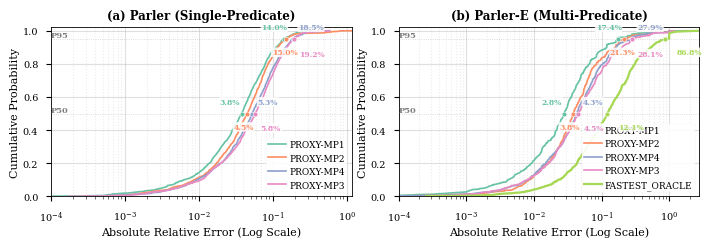

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 公共配置与路径
# ==========================================
agg_mode = 'count'
TARGET_BUDGET = 0.1
MARK_PERCENTILES = [0.50, 0.95]

# 统一输出路径
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "combined_proxy_quality_cdf.pdf")

# ==========================================
# 1.1 数据集 1 (Parler - 单谓词) 配置
# ==========================================
dataset_1 = 'dataset_three'
dataset_name_1 = 'Parler'
FASTEST_ORACLE_file_1 = f'FASTEST_ORACLE_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
base_dir_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/efficiency"
path_fastest_oracle_1 = os.path.join(base_dir_1, FASTEST_ORACLE_file_1)
path_ablation_1 = os.path.join(base_dir_1, f"proxy_quality_ablation_{agg_mode}.csv")

RAW_PROXY_LABEL_MAP_1 = {
    "POSSA_Q1_Low": "PROXY-MP4",
    "POSSA_Q2_Med": "PROXY-MP3",
    "POSSA_Q3_High": "PROXY-MP2",
    "POSSA_Q4_Best": "PROXY-MP1",
}

# ==========================================
# 1.2 数据集 2 (Parler-E - 多谓词) 配置
# ==========================================
dataset_2 = 'dataset_test'
dataset_name_2 = 'Parler-E'  
FASTEST_ORACLE_file_2 = f'FastestO_budget_curve_{agg_mode}.csv'  # 保持读取原文件名防止找不到文件

T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json"
if not os.path.exists(T_TRUE_JSON_2):
    T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

base_dir_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/efficiency"
path_fastest_oracle_2 = os.path.join(base_dir_2, FASTEST_ORACLE_file_2)
path_ablation_2 = os.path.join(base_dir_2, "proxy_quality_multipred_ablation_count.csv")

RAW_PROXY_LABEL_MAP_2 = {
    "POSSA_Q4_Low": "PROXY-MP4",
    "POSSA_Q3_Med": "PROXY-MP3",
    "POSSA_Q2_High": "PROXY-MP2",
    "POSSA_Q1_Best": "PROXY-MP1",
}

# ==========================================
# 1.3 统一显示顺序与防重叠偏移量 (POSSA 已改成 PROXY, Fastest_O 改成 FASTEST_ORACLE)
# ==========================================
DISPLAY_ORDER = [
    "PROXY-MP1",
    "PROXY-MP2",
    "PROXY-MP4",
    "PROXY-MP3",
    "FASTEST_ORACLE",
]

OFFSETS = {
    "PROXY-MP1": (-16, 7),   
    "PROXY-MP2": (-10, -11), 
    "PROXY-MP4": (4, 7),     
    "PROXY-MP3": (4, -12), 
    "FASTEST_ORACLE": (8, -11)     
}

# ==========================================
# 2. IEEE / ICDE 论文紧凑排版规范样式设置
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,   # 确保 TrueType 嵌入，避免投稿系统报错
    "ps.fonttype": 42,
    "font.family": "serif",  # 使用 Serif 字体配合 LaTeX 中的 Times Font 风格
    "font.size": 7.5,
    "axes.labelsize": 8.0,
    "axes.titlesize": 8.5,
    "legend.fontsize": 6.5,
    "xtick.labelsize": 7.0,
    "ytick.labelsize": 7.0,
    "axes.linewidth": 0.6,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.2
})

# ==========================================
# 3. 辅助数据处理函数
# ==========================================
def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

def load_data(t_true_path, ablation_path, fast_oracle_path, raw_label_map):
    with open(t_true_path, "r") as f:
        t_true_map = json.load(f)

    # 读取消融数据
    df_ablation = pd.read_csv(ablation_path)
    df_ablation = standardize_name(df_ablation)
    df_ablation = df_ablation[df_ablation["method"].isin(raw_label_map.keys())].copy()
    df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
    df_ablation["method"] = df_ablation["method"].map(raw_label_map)

    df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
    df_ablation["T_true"] = df_ablation["query_graph"].map(t_true_map)
    df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
    df_ablation = compute_are(df_ablation, "T_hat")

    data_map = {}
    for label in DISPLAY_ORDER:
        if label == "FASTEST_ORACLE":
            continue
        tmp = df_ablation[df_ablation["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp

    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    for label in list(data_map.keys()):
        df = data_map[label]
        data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

    # 读取 Oracle 数据 (并将内部标识统一设为 FASTEST_ORACLE)
    if os.path.exists(fast_oracle_path):
        df_fast = pd.read_csv(fast_oracle_path)
        df_fast = standardize_name(df_fast)
        if "T_hat" in df_fast.columns:
            df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
            df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
            df_fast["T_true"] = df_fast["query_graph"].map(t_true_map)
            df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
            df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
            if not df_fast.empty:
                df_fast = compute_are(df_fast, "T_hat")
                data_map["FASTEST_ORACLE"] = df_fast

    return data_map

# 加载两个数据集
data_map_1 = load_data(T_TRUE_JSON_1, path_ablation_1, path_fastest_oracle_1, RAW_PROXY_LABEL_MAP_1)
data_map_2 = load_data(T_TRUE_JSON_2, path_ablation_2, path_fastest_oracle_2, RAW_PROXY_LABEL_MAP_2)

# ==========================================
# 4. 创建 1 Row × 2 Columns 的合并图形
# ==========================================
# 7.0 英寸能完美适配 IEEE 双栏文档中的单行通栏宽度，高度设定为 2.3 英寸，结构非常紧凑
fig, axes = plt.subplots(1, 2, figsize=(7.0, 2.3))

palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))

def plot_cdf(ax, data_map, title):
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())

    positive_are = [x for x in all_are if x > 0]
    min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
    upper_focus = max(np.quantile(all_are, 1.0), min_are * 10)

    color_iter = iter(palette)

    for label in DISPLAY_ORDER:
        if label not in data_map:
            continue

        df = data_map[label]
        subset = df["ARE"].sort_values()
        if subset.empty:
            continue

        n = len(subset)
        y_vals = np.arange(1, n + 1) / n

        ls = "-"
        lw = 1.6 if "FASTEST_ORACLE" in label else 1.2
        color = next(color_iter)

        ax.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)

        # 标注百分位数
        if MARK_PERCENTILES:
            for p in MARK_PERCENTILES:
                idx = int(p * n) - 1
                idx = max(0, min(idx, n - 1))
                val_x = subset.iloc[idx]
                
                # 白色描边小圆点
                ax.scatter(val_x, p, color=color, s=12, zorder=5, edgecolors='white', linewidth=0.4)
                
                off_x, off_y = OFFSETS.get(label, (5, 5))
                
                # 标注百分比
                ax.annotate(
                    f"{val_x * 100:.1f}%",
                    xy=(val_x, p),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=5.5,
                    fontweight="bold",
                    color=color,
                    bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.85, ec="none"),
                    zorder=6
                )

    ax.set_title(title, pad=6, fontweight="bold")
    ax.set_xlabel("Absolute Relative Error (Log Scale)", labelpad=2)
    ax.grid(True, which="major", linestyle="-", alpha=0.4)
    ax.grid(True, which="minor", linestyle=":", alpha=0.25)

    ax.set_xscale("log")
    ax.set_xlim(min_are, upper_focus)
    ax.set_ylim(0, 1.02)

    for p in MARK_PERCENTILES:
        ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.6)
        ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=6.0, fontweight="bold")

    ax.legend(loc="lower right", frameon=True, framealpha=0.9, edgecolor="0.95", handletextpad=0.3, borderpad=0.25)

# 绘制左子图 (a)
plot_cdf(axes[0], data_map_1, "(a) Parler (Single-Predicate)")
axes[0].set_ylabel("Cumulative Probability", labelpad=2)

# 绘制右子图 (b)
plot_cdf(axes[1], data_map_2, "(b) Parler-E (Multi-Predicate)")
# 隐藏右边子图的y轴标签，共享左边空间以节省版面宽度（或者保留以提高独立可读性，这里保留以符合常规学术图表对齐要求）
axes[1].set_ylabel("Cumulative Probability", labelpad=2)

# ==========================================
# 5. 保存图表
# ==========================================
plt.tight_layout(pad=0.1)
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.01)
print(f"[OK] 合并 CDF PDF 图已成功导出至: {out_pdf}")
plt.show()
plt.close(fig)

findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found becau

✅ 符合 IEEE 极限单栏（3.5 英寸）排版的并排 CDF 图已成功导出: /home/wangshuo/resource/paper_figuires/combined_proxy_quality_cdf.pdf


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

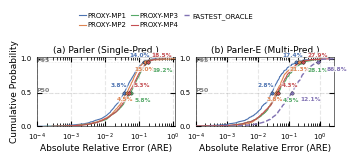

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 公共配置与路径
# ==========================================
agg_mode = 'count'
TARGET_BUDGET = 0.1
MARK_PERCENTILES = [0.50, 0.95]

# 统一输出路径
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "combined_proxy_quality_cdf.pdf")

# ==========================================
# 1.1 数据集 1 (Parler - 单谓词) 配置
# ==========================================
dataset_1 = 'dataset_three'
dataset_name_1 = 'Parler'
FASTEST_ORACLE_file_1 = f'FASTEST_ORACLE_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
base_dir_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/efficiency"
path_fastest_oracle_1 = os.path.join(base_dir_1, FASTEST_ORACLE_file_1)
path_ablation_1 = os.path.join(base_dir_1, f"proxy_quality_ablation_{agg_mode}.csv")

RAW_PROXY_LABEL_MAP_1 = {
    "POSSA_Q1_Low": "PROXY-MP4",
    "POSSA_Q2_Med": "PROXY-MP3",
    "POSSA_Q3_High": "PROXY-MP2",
    "POSSA_Q4_Best": "PROXY-MP1",
}

# ==========================================
# 1.2 数据集 2 (Parler-E - 多谓词) 配置
# ==========================================
dataset_2 = 'dataset_test'
dataset_name_2 = 'Parler-E'  
FASTEST_ORACLE_file_2 = f'FastestO_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json"
if not os.path.exists(T_TRUE_JSON_2):
    T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

base_dir_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/efficiency"
path_fastest_oracle_2 = os.path.join(base_dir_2, FASTEST_ORACLE_file_2)
path_ablation_2 = os.path.join(base_dir_2, "proxy_quality_multipred_ablation_count.csv")

RAW_PROXY_LABEL_MAP_2 = {
    "POSSA_Q4_Low": "PROXY-MP4",
    "POSSA_Q3_Med": "PROXY-MP3",
    "POSSA_Q2_High": "PROXY-MP2",
    "POSSA_Q1_Best": "PROXY-MP1",
}

# ==========================================
# 1.3 统一显示顺序与【微型版】防重叠偏移量
# ==========================================
DISPLAY_ORDER = [
    "PROXY-MP1",
    "PROXY-MP2",
    "PROXY-MP3",
    "PROXY-MP4",
    "FASTEST_ORACLE",
]

# 单栏微型视窗下，重新精调文字相对实点的像素偏移，防止重叠
OFFSETS = {
    "PROXY-MP1": (-10, 4),   
    "PROXY-MP2": (-7, -6), 
    "PROXY-MP3": (3, -7), 
    "PROXY-MP4": (3, 4),     
    "FASTEST_ORACLE": (6, -6)     
}

# ==========================================
# 2. IEEE / ICDE 极限单栏紧凑样式设置 (3.5英寸单栏双图)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # 标准 Times New Roman 字体
    "mathtext.fontset": "stix",  
    "font.size": 5.5,                   # 全局字号极限微调，保证单栏容纳度
    "axes.labelsize": 6.5,              # 坐标轴标题字号
    "axes.titlesize": 6.5,              # 子图标题 (a) (b)
    "legend.fontsize": 5.0,             # 微型图例字号
    "xtick.labelsize": 5.0,             # X 轴刻度
    "ytick.labelsize": 5.0,             # Y 轴刻度
    "axes.linewidth": 0.4,              # 边框线条细化
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8              # 曲线线宽变细，防止在小图里显得粗糙
})

# ==========================================
# 3. 辅助数据处理函数
# ==========================================
def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

def load_data(t_true_path, ablation_path, fast_oracle_path, raw_label_map):
    with open(t_true_path, "r") as f:
        t_true_map = json.load(f)

    df_ablation = pd.read_csv(ablation_path)
    df_ablation = standardize_name(df_ablation)
    df_ablation = df_ablation[df_ablation["method"].isin(raw_label_map.keys())].copy()
    df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
    df_ablation["method"] = df_ablation["method"].map(raw_label_map)

    df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
    df_ablation["T_true"] = df_ablation["query_graph"].map(t_true_map)
    df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
    df_ablation = compute_are(df_ablation, "T_hat")

    data_map = {}
    for label in DISPLAY_ORDER:
        if label == "FASTEST_ORACLE":
            continue
        tmp = df_ablation[df_ablation["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp

    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    for label in list(data_map.keys()):
        df = data_map[label]
        data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

    if os.path.exists(fast_oracle_path):
        df_fast = pd.read_csv(fast_oracle_path)
        df_fast = standardize_name(df_fast)
        if "T_hat" in df_fast.columns:
            df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
            df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
            df_fast["T_true"] = df_fast["query_graph"].map(t_true_map)
            df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
            df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
            if not df_fast.empty:
                df_fast = compute_are(df_fast, "T_hat")
                data_map["FASTEST_ORACLE"] = df_fast

    return data_map

# 加载数据
data_map_1 = load_data(T_TRUE_JSON_1, path_ablation_1, path_fastest_oracle_1, RAW_PROXY_LABEL_MAP_1)
data_map_2 = load_data(T_TRUE_JSON_2, path_ablation_2, path_fastest_oracle_2, RAW_PROXY_LABEL_MAP_2)

# ==========================================
# 4. 创建 1 Row × 2 Columns 的合并图形 (单栏极限微型组图)
# ==========================================
# 【已修改】尺寸严格设为 (3.5, 1.5) 英寸，完全符合 IEEE 论文的单栏尺寸限值
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.5))

palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

global_handles, global_labels = [], []
method_added = set()

def plot_cdf(ax, data_map, title, is_left=False):
    global global_handles, global_labels, method_added
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())

    positive_are = [x for x in all_are if x > 0]
    min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
    upper_focus = max(np.quantile(all_are, 1.0), min_are * 10)

    color_iter = iter(palette)

    for label in DISPLAY_ORDER:
        if label not in data_map:
            continue

        df = data_map[label]
        subset = df["ARE"].sort_values()
        if subset.empty:
            continue

        n = len(subset)
        y_vals = np.arange(1, n + 1) / n

        ls = "--" if "FASTEST_ORACLE" in label else "-"
        lw = 1.0 if "FASTEST_ORACLE" in label else 0.8
        color = next(color_iter)

        line, = ax.plot(subset, y_vals, linewidth=lw, linestyle=ls, color=color, zorder=3)

        if label not in method_added:
            global_handles.append(line)
            global_labels.append(label)
            method_added.add(label)

        # 标注百分位数 (极小视窗下微缩至 s=6 散点，4.2pt 字体)
        if MARK_PERCENTILES:
            for p in MARK_PERCENTILES:
                idx = int(p * n) - 1
                idx = max(0, min(idx, n - 1))
                val_x = subset.iloc[idx]
                
                ax.scatter(val_x, p, color=color, s=6, zorder=4, edgecolors='black', linewidth=0.2)
                
                off_x, off_y = OFFSETS.get(label, (5, 5))
                
                ax.annotate(
                    f"{val_x * 100:.1f}%",
                    xy=(val_x, p),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=4.2,
                    fontweight="bold",
                    color=color,
                    bbox=dict(boxstyle="round,pad=0.08", fc="white", alpha=0.75, ec="none"),
                    zorder=5
                )

    ax.set_title(title, pad=3)
    ax.set_xlabel("Absolute Relative Error (ARE)", labelpad=1)
    
    # 精简网格
    ax.grid(True, which="major", linestyle="--", alpha=0.3)
    ax.grid(False, which="minor")

    ax.set_xscale("log")
    ax.set_xlim(min_are, upper_focus)
    ax.set_ylim(0, 1.02)

    ax.tick_params(direction='in', which='both', top=True, right=True)

    for p in MARK_PERCENTILES:
        ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.4)
        ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=4.5, fontweight="bold")

# 绘制左子图 (a) 
plot_cdf(axes[0], data_map_1, "(a) Parler (Single-Pred.)", is_left=True)
axes[0].set_ylabel("Cumulative Probability", labelpad=1)

# 绘制右子图 (b) 
plot_cdf(axes[1], data_map_2, "(b) Parler-E (Multi-Pred.)", is_left=False)

# ==========================================
# 5. 极限空间保存与排版优化
# ==========================================
# 【已修改】极限压缩子图左右边缘、留白和 wspace (子图间距降至 0.15) 确保绘图空间最大化
plt.subplots_adjust(top=0.68, bottom=0.22, left=0.13, right=0.98, wspace=0.15)

# 【已修改】在 3.5 英寸物理宽度内，一排无法容纳 5 个图例。在此强制使用双行排版 (ncol=3)
# 同时压缩了图例符号长度(handlelength)和列间距(columnspacing)以防溢出边界
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ 符合 IEEE 极限单栏（3.5 英寸）排版的并排 CDF 图已成功导出: {out_pdf}")
plt.show()
plt.close(fig)

✅ 符合 IEEE 单栏（3.5 英寸）物理宽度缩窄且饱满填满的并排 CDF 图已成功导出: /home/wangshuo/resource/paper_figuires/combined_proxy_quality_cdf.pdf


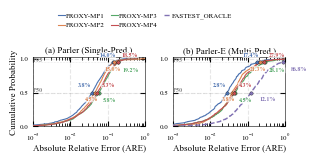

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 公共配置与路径
# ==========================================
agg_mode = 'count'
TARGET_BUDGET = 0.1
MARK_PERCENTILES = [0.50, 0.95]

# 统一输出路径
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "combined_proxy_quality_cdf.pdf")

# ==========================================
# 1.1 数据集 1 (Parler - 单谓词) 配置
# ==========================================
dataset_1 = 'dataset_three'
dataset_name_1 = 'Parler'
FASTEST_ORACLE_file_1 = f'FASTEST_ORACLE_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
base_dir_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/efficiency"
path_fastest_oracle_1 = os.path.join(base_dir_1, FASTEST_ORACLE_file_1)
path_ablation_1 = os.path.join(base_dir_1, f"proxy_quality_ablation_{agg_mode}.csv")

RAW_PROXY_LABEL_MAP_1 = {
    "POSSA_Q1_Low": "PROXY-MP4",
    "POSSA_Q2_Med": "PROXY-MP3",
    "POSSA_Q3_High": "PROXY-MP2",
    "POSSA_Q4_Best": "PROXY-MP1",
}

# ==========================================
# 1.2 数据集 2 (Parler-E - 多谓词) 配置
# ==========================================
dataset_2 = 'dataset_test'
dataset_name_2 = 'Parler-E'  
FASTEST_ORACLE_file_2 = f'FastestO_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json"
if not os.path.exists(T_TRUE_JSON_2):
    T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

base_dir_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/efficiency"
path_fastest_oracle_2 = os.path.join(base_dir_2, FASTEST_ORACLE_file_2)
path_ablation_2 = os.path.join(base_dir_2, "proxy_quality_multipred_ablation_count.csv")

RAW_PROXY_LABEL_MAP_2 = {
    "POSSA_Q4_Low": "PROXY-MP4",
    "POSSA_Q3_Med": "PROXY-MP3",
    "POSSA_Q2_High": "PROXY-MP2",
    "POSSA_Q1_Best": "PROXY-MP1",
}

# ==========================================
# 1.3 统一显示顺序与【微型版】防重叠偏移量
# ==========================================
DISPLAY_ORDER = [
    "PROXY-MP1",
    "PROXY-MP2",
    "PROXY-MP3",
    "PROXY-MP4",
    "FASTEST_ORACLE",
]

# 单栏微型视窗下，重新精调文字相对实点的像素偏移，防止重叠
OFFSETS = {
    "PROXY-MP1": (-10, 4),   
    "PROXY-MP2": (-7, -6), 
    "PROXY-MP3": (3, -7), 
    "PROXY-MP4": (3, 4),     
    "FASTEST_ORACLE": (6, -6)     
}

# ==========================================
# 2. IEEE / ICDE 极限单栏紧凑样式设置 (3.5英寸单栏双图)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # 标准 Times New Roman 字体
    "mathtext.fontset": "stix",  
    "font.size": 5.5,                   
    "axes.labelsize": 6.5,              
    "axes.titlesize": 6.5,              
    "legend.fontsize": 5.0,             
    "xtick.labelsize": 5.0,             
    "ytick.labelsize": 5.0,             
    "axes.linewidth": 0.4,              
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8              
})

# ==========================================
# 3. 辅助数据处理函数
# ==========================================
def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

def load_data(t_true_path, ablation_path, fast_oracle_path, raw_label_map):
    with open(t_true_path, "r") as f:
        t_true_map = json.load(f)

    df_ablation = pd.read_csv(ablation_path)
    df_ablation = standardize_name(df_ablation)
    df_ablation = df_ablation[df_ablation["method"].isin(raw_label_map.keys())].copy()
    df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
    df_ablation["method"] = df_ablation["method"].map(raw_label_map)

    df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
    df_ablation["T_true"] = df_ablation["query_graph"].map(t_true_map)
    df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
    df_ablation = compute_are(df_ablation, "T_hat")

    data_map = {}
    for label in DISPLAY_ORDER:
        if label == "FASTEST_ORACLE":
            continue
        tmp = df_ablation[df_ablation["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp

    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    for label in list(data_map.keys()):
        df = data_map[label]
        data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

    if os.path.exists(fast_oracle_path):
        df_fast = pd.read_csv(fast_oracle_path)
        df_fast = standardize_name(df_fast)
        if "T_hat" in df_fast.columns:
            df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
            df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
            df_fast["T_true"] = df_fast["query_graph"].map(t_true_map)
            df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
            df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
            if not df_fast.empty:
                df_fast = compute_are(df_fast, "T_hat")
                data_map["FASTEST_ORACLE"] = df_fast

    return data_map

# 加载数据
data_map_1 = load_data(T_TRUE_JSON_1, path_ablation_1, path_fastest_oracle_1, RAW_PROXY_LABEL_MAP_1)
data_map_2 = load_data(T_TRUE_JSON_2, path_ablation_2, path_fastest_oracle_2, RAW_PROXY_LABEL_MAP_2)

# ==========================================
# 4. 创建合并图形 (单栏极限微型组图)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.5))

palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

global_handles, global_labels = [], []
method_added = set()

def plot_cdf(ax, data_map, title, is_left=False):
    global global_handles, global_labels, method_added
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())

    # 【已修改】利用分位数自动、紧凑地对齐横坐标上下界，消除两侧无用空白，让曲线“填满”图表 [2]
    positive_are = [x for x in all_are if x > 0]
    if positive_are:
        p2 = np.percentile(positive_are, 2)
        p98 = np.percentile(positive_are, 98)
        
        # 将最小边界向下舍入到最近的 log decade，最大边界向上舍入
        min_are = 10 ** np.floor(np.log10(p2)) if p2 > 0 else 1e-3
        upper_focus = 10 ** np.ceil(np.log10(p98)) if p98 > 0 else 1.0
        
        # 加设安全边界防御，防止尺度异常
        min_are = max(1e-4, min(1e-2, min_are))
        upper_focus = min(10.0, max(1.0, upper_focus))
    else:
        min_are = 1e-3
        upper_focus = 1.0

    color_iter = iter(palette)

    for label in DISPLAY_ORDER:
        if label not in data_map:
            continue

        df = data_map[label]
        subset = df["ARE"].sort_values()
        if subset.empty:
            continue

        n = len(subset)
        y_vals = np.arange(1, n + 1) / n

        ls = "--" if "FASTEST_ORACLE" in label else "-"
        lw = 1.0 if "FASTEST_ORACLE" in label else 0.8
        color = next(color_iter)

        line, = ax.plot(subset, y_vals, linewidth=lw, linestyle=ls, color=color, zorder=3)

        if label not in method_added:
            global_handles.append(line)
            global_labels.append(label)
            method_added.add(label)

        if MARK_PERCENTILES:
            for p in MARK_PERCENTILES:
                idx = int(p * n) - 1
                idx = max(0, min(idx, n - 1))
                val_x = subset.iloc[idx]
                
                ax.scatter(val_x, p, color=color, s=6, zorder=4, edgecolors='black', linewidth=0.2)
                
                off_x, off_y = OFFSETS.get(label, (5, 5))
                
                ax.annotate(
                    f"{val_x * 100:.1f}%",
                    xy=(val_x, p),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=4.2,
                    fontweight="bold",
                    color=color,
                    bbox=dict(boxstyle="round,pad=0.08", fc="white", alpha=0.75, ec="none"),
                    zorder=5
                )

    ax.set_title(title, pad=3)
    ax.set_xlabel("Absolute Relative Error (ARE)", labelpad=1)
    
    ax.grid(True, which="major", linestyle="--", alpha=0.3)
    ax.grid(False, which="minor")

    ax.set_xscale("log")
    ax.set_xlim(min_are, upper_focus)
    ax.set_ylim(0, 1.02)

    ax.tick_params(direction='in', which='both', top=True, right=True)

    for p in MARK_PERCENTILES:
        ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.4)
        ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=4.5, fontweight="bold")

# 绘制左子图 (a) 
plot_cdf(axes[0], data_map_1, "(a) Parler (Single-Pred.)", is_left=True)
axes[0].set_ylabel("Cumulative Probability", labelpad=1)

# 绘制右子图 (b) 
plot_cdf(axes[1], data_map_2, "(b) Parler-E (Multi-Pred.)", is_left=False)

# ==========================================
# 5. 极限空间保存与排版优化 (物理缩窄优化)
# ==========================================
# 【已修改】将 left 调大至 0.18，right 调小至 0.90，wspace 增至 0.25 [1]
# 这样可以在不破坏 3.5 英寸总宽度的前提下，在两侧留下白边，从而强行将两张子图在物理上“变窄”
plt.subplots_adjust(top=0.68, bottom=0.22, left=0.18, right=0.90, wspace=0.25)

fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.02),
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ 符合 IEEE 单栏（3.5 英寸）物理宽度缩窄且饱满填满的并排 CDF 图已成功导出: {out_pdf}")
plt.show()
plt.close(fig)

✅ 符合 IEEE 单栏（3.5 英寸）物理宽度缩窄、消除死白、无加粗的规范图表已导出: /home/wangshuo/resource/paper_figuires/combined_proxy_quality_cdf.pdf


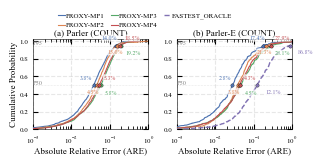

In [4]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 公共配置与路径
# ==========================================
agg_mode = 'count'
TARGET_BUDGET = 0.1
MARK_PERCENTILES = [0.50, 0.95]

# 统一输出路径
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, "combined_proxy_quality_cdf.pdf")

# ==========================================
# 1.1 数据集 1 (Parler - 单谓词) 配置
# ==========================================
dataset_1 = 'dataset_three'
dataset_name_1 = 'Parler'
FASTEST_ORACLE_file_1 = f'FASTEST_ORACLE_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
base_dir_1 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_1}/results/efficiency"
path_fastest_oracle_1 = os.path.join(base_dir_1, FASTEST_ORACLE_file_1)
path_ablation_1 = os.path.join(base_dir_1, f"proxy_quality_ablation_{agg_mode}.csv")

RAW_PROXY_LABEL_MAP_1 = {
    "POSSA_Q1_Low": "PROXY-MP4",
    "POSSA_Q2_Med": "PROXY-MP3",
    "POSSA_Q3_High": "PROXY-MP2",
    "POSSA_Q4_Best": "PROXY-MP1",
}

# ==========================================
# 1.2 数据集 2 (Parler-E - 多谓词) 配置
# ==========================================
dataset_2 = 'dataset_test'
dataset_name_2 = 'Parler-E'  
FASTEST_ORACLE_file_2 = f'FastestO_budget_curve_{agg_mode}.csv'

T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json"
if not os.path.exists(T_TRUE_JSON_2):
    T_TRUE_JSON_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

base_dir_2 = f"/home/wangshuo/resource/datasets/parler_data/{dataset_2}/results/efficiency"
path_fastest_oracle_2 = os.path.join(base_dir_2, FASTEST_ORACLE_file_2)
path_ablation_2 = os.path.join(base_dir_2, "proxy_quality_multipred_ablation_count.csv")

RAW_PROXY_LABEL_MAP_2 = {
    "POSSA_Q4_Low": "PROXY-MP4",
    "POSSA_Q3_Med": "PROXY-MP3",
    "POSSA_Q2_High": "PROXY-MP2",
    "POSSA_Q1_Best": "PROXY-MP1",
}

# ==========================================
# 1.3 统一显示顺序与【微型版】防重叠偏移量
# ==========================================
DISPLAY_ORDER = [
    "PROXY-MP1",
    "PROXY-MP2",
    "PROXY-MP3",
    "PROXY-MP4",
    "FASTEST_ORACLE",
]

# 单栏微型视窗下，重新精调文字相对实点的像素偏移，防止重叠
OFFSETS = {
    "PROXY-MP1": (-10, 4),   
    "PROXY-MP2": (-7, -6), 
    "PROXY-MP3": (3, -7), 
    "PROXY-MP4": (3, 4),     
    "FASTEST_ORACLE": (6, -6)     
}

# ==========================================
# 2. IEEE / ICDE 极限单栏紧凑样式设置 (3.5英寸单栏双图)
# ==========================================
plt.rcParams.update({
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],  # 标准 Times New Roman 字体
    "mathtext.fontset": "stix",  
    "font.size": 5.5,                   
    "axes.labelsize": 6.5,              
    "axes.titlesize": 6.5,              
    "legend.fontsize": 5.0,             
    "xtick.labelsize": 5.0,             
    "ytick.labelsize": 5.0,             
    "axes.linewidth": 0.4,              
    "grid.linestyle": "--",
    "grid.alpha": 0.3,
    "lines.linewidth": 0.8              
})

# ==========================================
# 3. 辅助数据处理函数
# ==========================================
def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

def load_data(t_true_path, ablation_path, fast_oracle_path, raw_label_map):
    with open(t_true_path, "r") as f:
        t_true_map = json.load(f)

    df_ablation = pd.read_csv(ablation_path)
    df_ablation = standardize_name(df_ablation)
    df_ablation = df_ablation[df_ablation["method"].isin(raw_label_map.keys())].copy()
    df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
    df_ablation["method"] = df_ablation["method"].map(raw_label_map)

    df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
    df_ablation["T_true"] = df_ablation["query_graph"].map(t_true_map)
    df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
    df_ablation = compute_are(df_ablation, "T_hat")

    data_map = {}
    for label in DISPLAY_ORDER:
        if label == "FASTEST_ORACLE":
            continue
        tmp = df_ablation[df_ablation["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp

    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    for label in list(data_map.keys()):
        df = data_map[label]
        data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

    if os.path.exists(fast_oracle_path):
        df_fast = pd.read_csv(fast_oracle_path)
        df_fast = standardize_name(df_fast)
        if "T_hat" in df_fast.columns:
            df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
            df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
            df_fast["T_true"] = df_fast["query_graph"].map(t_true_map)
            df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
            df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
            if not df_fast.empty:
                df_fast = compute_are(df_fast, "T_hat")
                data_map["FASTEST_ORACLE"] = df_fast

    return data_map

# 加载数据
data_map_1 = load_data(T_TRUE_JSON_1, path_ablation_1, path_fastest_oracle_1, RAW_PROXY_LABEL_MAP_1)
data_map_2 = load_data(T_TRUE_JSON_2, path_ablation_2, path_fastest_oracle_2, RAW_PROXY_LABEL_MAP_2)

# ==========================================
# 4. 创建合并图形 (单栏极限微型组图)
# ==========================================
fig, axes = plt.subplots(1, 2, figsize=(3.5, 1.5))

palette = sns.color_palette("deep", n_colors=len(DISPLAY_ORDER))

global_handles, global_labels = [], []
method_added = set()

def plot_cdf(ax, data_map, title, is_left=False):
    global global_handles, global_labels, method_added
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())

    positive_are = [x for x in all_are if x > 0]
    if positive_are:
        p2 = np.percentile(positive_are, 2)
        p98 = np.percentile(positive_are, 98)
        
        min_are = 10 ** np.floor(np.log10(p2)) if p2 > 0 else 1e-3
        upper_focus = 10 ** np.ceil(np.log10(p98)) if p98 > 0 else 1.0
        
        min_are = max(1e-4, min(1e-2, min_are))
        upper_focus = min(10.0, max(1.0, upper_focus))
    else:
        min_are = 1e-3
        upper_focus = 1.0

    color_iter = iter(palette)

    for label in DISPLAY_ORDER:
        if label not in data_map:
            continue

        df = data_map[label]
        subset = df["ARE"].sort_values()
        if subset.empty:
            continue

        n = len(subset)
        y_vals = np.arange(1, n + 1) / n

        ls = "--" if "FASTEST_ORACLE" in label else "-"
        lw = 1.0 if "FASTEST_ORACLE" in label else 0.8
        color = next(color_iter)

        line, = ax.plot(subset, y_vals, linewidth=lw, linestyle=ls, color=color, zorder=3)

        if label not in method_added:
            global_handles.append(line)
            global_labels.append(label)
            method_added.add(label)

        if MARK_PERCENTILES:
            for p in MARK_PERCENTILES:
                idx = int(p * n) - 1
                idx = max(0, min(idx, n - 1))
                val_x = subset.iloc[idx]
                
                ax.scatter(val_x, p, color=color, s=6, zorder=4, edgecolors='black', linewidth=0.2)
                
                off_x, off_y = OFFSETS.get(label, (5, 5))
                
                # 🚨 【核心修改】：去除了 fontweight="bold"，与 RQ2 完全对齐
                ax.annotate(
                    f"{val_x * 100:.1f}%",
                    xy=(val_x, p),
                    xytext=(off_x, off_y),
                    textcoords="offset points",
                    fontsize=4.2,
                    color=color,
                    bbox=dict(boxstyle="round,pad=0.08", fc="white", alpha=0.75, ec="none"),
                    zorder=5
                )

    ax.set_title(title, pad=3)
    ax.set_xlabel("Absolute Relative Error (ARE)", labelpad=1)
    
    ax.grid(True, which="major", linestyle="--", alpha=0.3)
    ax.grid(False, which="minor")

    ax.set_xscale("log")
    ax.set_xlim(min_are, upper_focus)
    ax.set_ylim(0, 1.02)

    # 🚨 确保全部刻度和边框颜色纯黑向内
    ax.tick_params(direction='in', which='both', top=True, right=True, colors='black')

    for p in MARK_PERCENTILES:
        ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.4)
        # 🚨 【核心修改】：去除了 P50/P95 文本的 fontweight="bold"
        ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=4.5)

# 绘制左子图 (a) 
plot_cdf(axes[0], data_map_1, "(a) Parler (COUNT)", is_left=True)
axes[0].set_ylabel("Cumulative Probability", labelpad=1)

# 绘制右子图 (b) 
plot_cdf(axes[1], data_map_2, "(b) Parler-E (COUNT)", is_left=False)

# ==========================================
# 5. 极限空间保存与排版优化 (消除死白鸿沟)
# ==========================================
# 🚨 【核心修改 1】：将 top 从 0.68 大幅拉高到 0.82，彻底吃掉上方的多余死白空间！
plt.subplots_adjust(top=0.82, bottom=0.22, left=0.18, right=0.92, wspace=0.25)

# 🚨 【核心修改 2】：配合 top 的拉高，将图例锚点降至 1.04，让图例紧紧贴着子图的标题
fig.legend(global_handles, global_labels, loc='upper center', bbox_to_anchor=(0.5, 1.04),
           ncol=3, frameon=False, columnspacing=0.8, handletextpad=0.2, handlelength=1.0)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", dpi=300)
print(f"✅ 符合 IEEE 单栏（3.5 英寸）物理宽度缩窄、消除死白、无加粗的规范图表已导出: {out_pdf}")
plt.show()
plt.close(fig)

0. 构建最差情况下代理模式输出分布: 完全随机或得不到任何有效谓词满足信息

In [ ]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm

def add_worst_proxy_to_csvs(dataset_name="dataset_test"):
    base_path = f"/home/wangshuo/resource/datasets/parler_data/{dataset_name}"
    aggregated_dir = os.path.join(base_path, "results", "aggregated_results")
    
    if not os.path.exists(aggregated_dir):
        print(f"目录不存在: {aggregated_dir}")
        return

    csv_files = [f for f in os.listdir(aggregated_dir) if f.endswith('.csv')]
    
    print(f"开始处理 {len(csv_files)} 个文件...")
    for filename in tqdm(csv_files):
        filepath = os.path.join(aggregated_dir, filename)
        try:
            df = pd.read_csv(filepath)
            
            # === 修改这里 === 
            random_probs = np.random.uniform(low=0.001, high=0.999, size=len(df))
            df['worst_proxy_probability'] = [f"[{x}]" for x in random_probs]
            
            df.to_csv(filepath, index=False)
        except Exception as e:
            print(f"处理文件 {filename} 时出错: {e}")
            
    print("完成！已添加 worst_proxy_probability 列。")
if __name__ == "__main__":
    add_worst_proxy_to_csvs(dataset_name="dataset_three")

修改下面代码, 我有多个分布文件,ML1_proxy1b_probability_ML2_proxy1_probability \ ML1_proxy2b_probability_ML2_proxy1_probability
\ML1_proxy4b_probability_ML2_proxy1_probability \ ML1_proxy6b_probability_ML2_proxy1_probability ,分别对应四种代理模型组合
分别是 MP4 , MP3,MP1,MP2 ,各随机提取这些文件夹下的文件N_SAMPLES 个, 每个文件夹下的文件results_summary_run_x.csv 中都含有POSSA方法,绘制出这些POSSA方法再不同文件夹下结果的CDF曲线图, 还要读取results_summary_FaSTestO.csv 绘制结果作为参照

#### 1.1 线性横坐标

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
import json

# ==========================================
# 1. 配置
# ==========================================
dataset = 'dataset_test2'
fatestO_file = 'results_summary_FaSTestO.csv'
N_SAMPLES = 5
ENABLE_FASTESTO = True

T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

DISTRIBUTIONS = {
    "MP4": "ML1_proxy1b_probability_ML2_proxy1_probability",
    "MP3": "ML1_proxy2b_probability_ML2_proxy1_probability",
    "MP1": "ML1_proxy4b_probability_ML2_proxy1_probability",
    "MP2": "ML1_proxy6b_probability_ML2_proxy1_probability",
}

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO_file}"

print(f"Dataset: {dataset}")
print(f"Distributions: {list(DISTRIBUTIONS.keys())}")
print(f"T_true json: {T_TRUE_JSON}")

# ==========================================
# 2. 读取 T_true（唯一真值源）
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取 POSSA（四个分布）
# ==========================================
def load_possa_from_distribution(dist_name: str, label: str, n_samples: int):
    dist_dir = os.path.join(base_dir, dist_name)
    if not os.path.exists(dist_dir):
        print(f"[Error] 目录不存在: {dist_dir}")
        return None

    all_files = [f for f in os.listdir(dist_dir) if f.startswith("results_summary_run_") and f.endswith(".csv")]
    if not all_files:
        print(f"[Error] {dist_dir} 下未找到 results_summary_run_*.csv")
        return None

    selected_files = all_files if len(all_files) < n_samples else random.sample(all_files, n_samples)
    print(f"[INFO] {label} sampled files: {selected_files}")

    df_list = []
    for f in selected_files:
        p = os.path.join(dist_dir, f)
        try:
            df_list.append(pd.read_csv(p))
        except Exception as e:
            print(f"[Warning] 读取失败 {p}: {e}")

    if not df_list:
        return None

    df = pd.concat(df_list, ignore_index=True)
    df = standardize_name(df)

    # 必要列检查
    need_cols = {"query_basename", "method", "T_hat"}
    miss = need_cols - set(df.columns)
    if miss:
        print(f"[Error] {label} 缺少列: {miss}")
        return None

    df = df[df["method"] == "POSSA"].copy()

    # 用 JSON 的 T_true 统一赋值
    df["query_graph"] = df["query_basename"].apply(to_graph_name)
    df["T_true"] = df["query_graph"].map(T_TRUE_MAP)

    # 过滤无效 T_true
    df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
    if df.empty:
        return df

    df = compute_are(df, "T_hat")
    df["source"] = label
    return df

possa_by_label = {}
for label, dist in DISTRIBUTIONS.items():
    df_possa = load_possa_from_distribution(dist, label, N_SAMPLES)
    if df_possa is not None and not df_possa.empty:
        possa_by_label[label] = df_possa
        print(f"[OK] {label}: {len(df_possa)} rows")
    else:
        print(f"[WARN] {label}: 无可用 POSSA 数据")

if not possa_by_label:
    raise RuntimeError("没有任何 POSSA 数据可绘图。请检查四个分布目录或 T_true JSON。")

# POSSA 交集（仅在 POSSA 之间）
common_queries_possa = None
for label, df in possa_by_label.items():
    qset = set(df["query_basename"].unique())
    common_queries_possa = qset if common_queries_possa is None else common_queries_possa.intersection(qset)

print(f"[INFO] POSSA 共同查询数: {len(common_queries_possa)}")

for label in list(possa_by_label.keys()):
    df = possa_by_label[label]
    df = df[df["query_basename"].isin(common_queries_possa)].copy()
    possa_by_label[label] = df

# ==========================================
# 4. 读取 FaSTestO（参照曲线）
# ==========================================
df_fast = None
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)

    if "T_hat" not in df_fast.columns:
        print("[WARN] FaSTestO 缺少 T_hat 列，无法计算 ARE。")
        df_fast = None
    else:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        df_fast = df_fast[df_fast["query_basename"].isin(common_queries_possa)].copy()

        if df_fast.empty:
            print("[WARN] FaSTestO 过滤后为空，将不绘制。")
            df_fast = None
        else:
            df_fast = compute_are(df_fast, "T_hat")
            print(f"[OK] FaSTestO: {len(df_fast)} rows (aligned)")
else:
    print(f"[WARN] 未启用或未找到 FaSTestO 文件: {path_fastesto}")

# ==========================================
# 5. 绘制 CDF
# ==========================================
plt.style.use("seaborn-v0_8-paper")
plt.figure(figsize=(9, 6))

all_are = []
for df in possa_by_label.values():
    all_are.extend(df["ARE"].values.tolist())
if df_fast is not None:
    all_are.extend(df_fast["ARE"].values.tolist())

max_are = np.max(all_are) if all_are else 1.0
USE_LOG_SCALE = max_are > 5.0

palette = sns.color_palette("Set2", n_colors=len(possa_by_label) + (1 if df_fast is not None else 0))
color_iter = iter(palette)

plotted_any = False

for label, df in sorted(possa_by_label.items()):
    subset = df["ARE"].sort_values()
    if subset.empty:
        print(f"[WARN] {label} 在共同查询上为空，跳过绘制。")
        continue
    y_vals = np.arange(1, len(subset) + 1) / len(subset)
    plt.plot(subset, y_vals, label=f"POSSA-{label}", linewidth=2.0, color=next(color_iter))
    plotted_any = True

if df_fast is not None and not df_fast.empty:
    subset = df_fast["ARE"].sort_values()
    y_vals = np.arange(1, len(subset) + 1) / len(subset)
    plt.plot(subset, y_vals, label="FaSTestO", linewidth=2.5, linestyle="--", color=next(color_iter))
    plotted_any = True

plt.title("POSSA CDF under Different Proxy Distributions")
plt.xlabel("Absolute Relative Error" + (" (Log Scale)" if USE_LOG_SCALE else ""))
plt.ylabel("Cumulative Probability")
plt.grid(True, which="both", linestyle=":", alpha=0.6)

if USE_LOG_SCALE:
    plt.xscale("log")

if plotted_any:
    plt.legend(loc="lower right")
else:
    print("[ERROR] 没有任何曲线被绘制，请检查数据是否为空。")

plt.tight_layout()
plt.show()

#### 1.2 指数坐标

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
import json

# ==========================================
# 1. 配置
# ==========================================
dataset = 'dataset_test2'
fatestO_file = 'results_summary_FaSTestO.csv'
N_SAMPLES = 5
ENABLE_FASTESTO = True

T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

DISTRIBUTIONS = {
    "MP4": "ML1_proxy1b_probability_ML2_proxy1_probability",
    "MP3": "ML1_proxy2b_probability_ML2_proxy1_probability",
    "MP1": "ML1_proxy4b_probability_ML2_proxy1_probability",
    "MP2": "ML1_proxy6b_probability_ML2_proxy1_probability",
}

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO_file}"

print(f"Dataset: {dataset}")
print(f"Distributions: {list(DISTRIBUTIONS.keys())}")
print(f"T_true json: {T_TRUE_JSON}")

# ==========================================
# 2. 读取 T_true（唯一真值源）
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取 POSSA（四个分布）
# ==========================================
def load_possa_from_distribution(dist_name: str, label: str, n_samples: int):
    dist_dir = os.path.join(base_dir, dist_name)
    if not os.path.exists(dist_dir):
        print(f"[Error] 目录不存在: {dist_dir}")
        return None

    all_files = [f for f in os.listdir(dist_dir) if f.startswith("results_summary_run_") and f.endswith(".csv")]
    if not all_files:
        print(f"[Error] {dist_dir} 下未找到 results_summary_run_*.csv")
        return None

    selected_files = all_files if len(all_files) < n_samples else random.sample(all_files, n_samples)
    print(f"[INFO] {label} sampled files: {selected_files}")

    df_list = []
    for f in selected_files:
        p = os.path.join(dist_dir, f)
        try:
            df_list.append(pd.read_csv(p))
        except Exception as e:
            print(f"[Warning] 读取失败 {p}: {e}")

    if not df_list:
        return None

    df = pd.concat(df_list, ignore_index=True)
    df = standardize_name(df)

    need_cols = {"query_basename", "method", "T_hat"}
    miss = need_cols - set(df.columns)
    if miss:
        print(f"[Error] {label} 缺少列: {miss}")
        return None

    df = df[df["method"] == "POSSA"].copy()

    df["query_graph"] = df["query_basename"].apply(to_graph_name)
    df["T_true"] = df["query_graph"].map(T_TRUE_MAP)

    df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
    if df.empty:
        return df

    df = compute_are(df, "T_hat")
    df["source"] = label
    return df

possa_by_label = {}
for label, dist in DISTRIBUTIONS.items():
    df_possa = load_possa_from_distribution(dist, label, N_SAMPLES)
    if df_possa is not None and not df_possa.empty:
        possa_by_label[label] = df_possa
        print(f"[OK] {label}: {len(df_possa)} rows")
    else:
        print(f"[WARN] {label}: 无可用 POSSA 数据")

if not possa_by_label:
    raise RuntimeError("没有任何 POSSA 数据可绘图。请检查四个分布目录或 T_true JSON。")

# POSSA 交集（仅在 POSSA 之间）
common_queries_possa = None
for label, df in possa_by_label.items():
    qset = set(df["query_basename"].unique())
    common_queries_possa = qset if common_queries_possa is None else common_queries_possa.intersection(qset)

print(f"[INFO] POSSA 共同查询数: {len(common_queries_possa)}")

for label in list(possa_by_label.keys()):
    df = possa_by_label[label]
    df = df[df["query_basename"].isin(common_queries_possa)].copy()
    possa_by_label[label] = df

# ==========================================
# 4. 读取 FaSTestO（参照曲线）
# ==========================================
df_fast = None
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)

    if "T_hat" not in df_fast.columns:
        print("[WARN] FaSTestO 缺少 T_hat 列，无法计算 ARE。")
        df_fast = None
    else:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        df_fast = df_fast[df_fast["query_basename"].isin(common_queries_possa)].copy()

        if df_fast.empty:
            print("[WARN] FaSTestO 过滤后为空，将不绘制。")
            df_fast = None
        else:
            df_fast = compute_are(df_fast, "T_hat")
            print(f"[OK] FaSTestO: {len(df_fast)} rows (aligned)")
else:
    print(f"[WARN] 未启用或未找到 FaSTestO 文件: {path_fastesto}")

# ==========================================
# 5. 绘制 CDF（log-x + 强化小误差差距）
# ==========================================
plt.style.use("seaborn-v0_8-paper")
plt.figure(figsize=(9, 6))

all_are = []
for df in possa_by_label.values():
    all_are.extend(df["ARE"].values.tolist())
if df_fast is not None:
    all_are.extend(df_fast["ARE"].values.tolist())

if not all_are:
    raise RuntimeError("没有可用于绘图的 ARE 数据。")

# log x 不能含 0
min_are = max(1e-4, np.min([x for x in all_are if x > 0]))
max_are = np.max(all_are)

# 重点放大小误差区间：取 95% 分位上限（可按需要改为 90%/99%）
upper_focus = np.quantile(all_are, 1.0)
upper_focus = max(upper_focus, min_are * 10)

palette = sns.color_palette("Set2", n_colors=len(possa_by_label) + (1 if df_fast is not None else 0))
color_iter = iter(palette)

plotted_any = False

for label, df in sorted(possa_by_label.items()):
    subset = df["ARE"].sort_values()
    if subset.empty:
        print(f"[WARN] {label} 在共同查询上为空，跳过绘制。")
        continue
    y_vals = np.arange(1, len(subset) + 1) / len(subset)
    plt.plot(subset, y_vals, label=f"POSSA-{label}", linewidth=2.0, color=next(color_iter))
    plotted_any = True

if df_fast is not None and not df_fast.empty:
    subset = df_fast["ARE"].sort_values()
    y_vals = np.arange(1, len(subset) + 1) / len(subset)
    plt.plot(subset, y_vals, label="FaSTestO", linewidth=2.5, linestyle="--", color=next(color_iter))
    plotted_any = True

plt.title("POSSA CDF under Different Proxy Distributions (Log-x, Focused)")
plt.xlabel("Absolute Relative Error (Log Scale)")
plt.ylabel("Cumulative Probability")
plt.grid(True, which="both", linestyle=":", alpha=0.6)

plt.xscale("log")
plt.xlim(min_are, upper_focus)

if plotted_any:
    plt.legend(loc="lower right")
else:
    print("[ERROR] 没有任何曲线被绘制，请检查数据是否为空。")

plt.tight_layout()
plt.show()

#### 1.3 仿照上面生成格式和评价标准也输出, 同时在CDF图中可以选择标记P50,P95等点

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
import json

# ==========================================
# 1. 配置
# ==========================================
dataset = 'dataset_three'
fatestO_file = 'results_summary_FaSTestO.csv'
N_SAMPLES = 5
ENABLE_FASTESTO = True

# 定义要在 CDF 图上标记的关键分位点 (例如: P50 和 P95)
MARK_PERCENTILES = [0.50, 0.95] 

# T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"
T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

# DISTRIBUTIONS = {
#     "MP4": "ML1_proxy1b_probability_ML2_proxy1_probability",
#     "MP3": "ML1_proxy2b_probability_ML2_proxy1_probability",
#     "MP1": "ML1_proxy4b_probability_ML2_proxy1_probability",
#     "MP2": "ML1_proxy6b_probability_ML2_proxy1_probability",
# }
DISTRIBUTIONS = {
    "MP4": "ML1_proxy1b_probability",
    "MP3": "ML1_proxy2b_probability",
    "MP1": "ML1_proxy4b_probability",
    "MP2": "ML1_proxy6b_probability",
}
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/result_summarys"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/{fatestO_file}"

print(f"Dataset: {dataset}")
print(f"Distributions: {list(DISTRIBUTIONS.keys())}")
print(f"T_true json: {T_TRUE_JSON}")

# ==========================================
# 2. 读取 T_true（唯一真值源）
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    # ARE 是比率 (例如 0.1 代表 10% 误差)
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取 POSSA（四个分布）
# ==========================================
def load_possa_from_distribution(dist_name: str, label: str, n_samples: int):
    dist_dir = os.path.join(base_dir, dist_name)
    if not os.path.exists(dist_dir):
        print(f"[Error] 目录不存在: {dist_dir}")
        return None

    all_files = [f for f in os.listdir(dist_dir) if f.startswith("results_summary_run_") and f.endswith(".csv")]
    if not all_files:
        print(f"[Error] {dist_dir} 下未找到 results_summary_run_*.csv")
        return None

    selected_files = all_files if len(all_files) < n_samples else random.sample(all_files, n_samples)
    
    df_list = []
    for f in selected_files:
        p = os.path.join(dist_dir, f)
        try:
            df_list.append(pd.read_csv(p))
        except Exception as e:
            print(f"[Warning] 读取失败 {p}: {e}")

    if not df_list:
        return None

    df = pd.concat(df_list, ignore_index=True)
    df = standardize_name(df)

    need_cols = {"query_basename", "method", "T_hat"}
    miss = need_cols - set(df.columns)
    if miss:
        print(f"[Error] {label} 缺少列: {miss}")
        return None

    df = df[df["method"] == "POSSA"].copy()

    df["query_graph"] = df["query_basename"].apply(to_graph_name)
    df["T_true"] = df["query_graph"].map(T_TRUE_MAP)

    df = df[df["T_true"].notna() & (df["T_true"] > 0)].copy()
    if df.empty:
        return df

    df = compute_are(df, "T_hat")
    df["source"] = label
    return df

data_map = {} # 用于存储所有要对比的方法数据

# 加载 POSSA
for label, dist in DISTRIBUTIONS.items():
    df_possa = load_possa_from_distribution(dist, label, N_SAMPLES)
    if df_possa is not None and not df_possa.empty:
        data_map[f"POSSA-{label}"] = df_possa
        print(f"[OK] {label}: {len(df_possa)} rows")
    else:
        print(f"[WARN] {label}: 无可用 POSSA 数据")

if not data_map:
    raise RuntimeError("没有任何 POSSA 数据可绘图。请检查目录或 T_true JSON。")

# 计算 POSSA 交集
common_queries = None
for label, df in data_map.items():
    qset = set(df["query_basename"].unique())
    common_queries = qset if common_queries is None else common_queries.intersection(qset)

print(f"[INFO] POSSA 共同查询数: {len(common_queries)}")

# ==========================================
# 4. 读取 FaSTestO（参照曲线）
# ==========================================
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)

    if "T_hat" in df_fast.columns:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        
        # 仅保留共同查询
        df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()

        if not df_fast.empty:
            df_fast = compute_are(df_fast, "T_hat")
            data_map["FaSTestO"] = df_fast
            print(f"[OK] FaSTestO: {len(df_fast)} rows (aligned)")
        else:
             print("[WARN] FaSTestO 过滤后为空。")
    else:
        print("[WARN] FaSTestO 缺少 T_hat 列。")
else:
    print(f"[WARN] FaSTestO 跳过: {path_fastesto}")

# 对所有数据应用共同查询过滤 (确保公平对比)
for label in list(data_map.keys()):
    df = data_map[label]
    data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

# ==========================================
# 5. 生成统计表格 (Summary Table)
# ==========================================
def print_summary_table(data_dict):
    headers = ["Method", "Mean", "Median", "P50", "P75", "P90", "P95", "Max"]
    # 定义表头格式
    header_fmt = "{:<20} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10}"
    row_fmt    = "{:<20} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10}"
    
    line_len = 113
    print("\n" + "="*line_len)
    print(f"{'AQP Evaluation Metrics Summary (Dynamic Percentiles)':^{line_len}}")
    print("="*line_len)
    print(header_fmt.format(*headers))
    print("-" * line_len)

    # 按名称排序输出
    for label in sorted(data_dict.keys()):
        df = data_dict[label]
        are_series = df["ARE"]
        
        # 计算统计量 (注意：ARE是小数，显示时需乘100变百分比)
        metrics = {
            "Mean":   are_series.mean() * 100,
            "Median": are_series.median() * 100,
            "P50":    np.percentile(are_series, 50) * 100,
            "P75":    np.percentile(are_series, 75) * 100,
            "P90":    np.percentile(are_series, 90) * 100,
            "P95":    np.percentile(are_series, 95) * 100,
            "Max":    are_series.max() * 100
        }
        
        # 格式化数值字符串
        f_metrics = [f"{v:.2f}%" for v in metrics.values()]
        
        print(row_fmt.format(label, *f_metrics))
    
    print("-" * line_len + "\n")

print_summary_table(data_map)

# ==========================================
# 6. 绘制 CDF (带标记)
# ==========================================
plt.style.use("seaborn-v0_8-paper")
plt.figure(figsize=(10, 6))

# 收集所有 ARE 以确定坐标轴范围
all_are = []
for df in data_map.values():
    all_are.extend(df["ARE"].values.tolist())

min_are = max(1e-4, np.min([x for x in all_are if x > 0]))
upper_focus = np.quantile(all_are, 1.0) # 聚焦 98% 的数据
upper_focus = max(upper_focus, min_are * 10)

palette = sns.color_palette("Set2", n_colors=len(data_map))
color_iter = iter(palette)

for label in sorted(data_map.keys()):
    df = data_map[label]
    # 排序 ARE
    subset = df["ARE"].sort_values()
    if subset.empty:
        continue
        
    n = len(subset)
    y_vals = np.arange(1, n + 1) / n
    
    # 确定线型
    ls = "--" if "FaSTestO" in label else "-"
    lw = 2.5 if "FaSTestO" in label else 2.0
    color = next(color_iter)
    
    # 绘制 CDF 曲线
    plt.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)
    
    # --- 添加 P50, P95 等标记点 ---
    if MARK_PERCENTILES:
        # 为了美观，仅在图例不是特别多的时候显示所有标记
        marker_x = []
        marker_y = []
        for p in MARK_PERCENTILES:
            # 找到最接近 percentile 的索引
            idx = int(p * n) - 1
            idx = max(0, min(idx, n - 1))
            val_x = subset.iloc[idx]
            
            marker_x.append(val_x)
            marker_y.append(p)
            
        # 绘制散点
        plt.scatter(marker_x, marker_y, color=color, s=40, zorder=5, edgecolors='white', linewidth=0.5)
    # ----------------------------

plt.title("CDF of Absolute Relative Error (ARE)")
plt.xlabel("Absolute Relative Error (Log Scale)")
plt.ylabel("Cumulative Probability")

# 设置网格
plt.grid(True, which="major", linestyle="-", alpha=0.5)
plt.grid(True, which="minor", linestyle=":", alpha=0.3)

plt.xscale("log")
plt.xlim(min_are, upper_focus)
plt.ylim(0, 1.05)

# 添加 y 轴的百分位辅助线（可选）
for p in MARK_PERCENTILES:
    plt.axhline(y=p, color='gray', linestyle=':', alpha=0.3, linewidth=1)
    plt.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=8)

plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

最新绘图脚本,为每个采样率绘制CDF图 V1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
import json

# ==========================================
# 1. 配置
# ==========================================
dataset = 'dataset_three' # 根据需要修改你的数据集名
fatestO_file = 'FastestO_budget_curve_count.csv'
ENABLE_FASTESTO = True

# 定义要在 CDF 图上标记的关键分位点 (例如: P50 和 P95)
MARK_PERCENTILES = [0.50, 0.95]

T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency/{fatestO_file}"
path_ablation = os.path.join(base_dir, "proxy_quality_ablation_count.csv")

# 只读取这个单文件里的 POSSA 消融结果
RAW_PROXY_LABEL_MAP = {
    "POSSA_Q0_Worst": "POSSA-MPW",
    "POSSA_Q1_Low": "POSSA-MP4",
    "POSSA_Q2_Med": "POSSA-MP3",
    "POSSA_Q3_High": "POSSA-MP2",
    "POSSA_Q4_Best": "POSSA-MP1",
}
DISPLAY_ORDER = [
    "POSSA-MP4",
    "POSSA-MP3",
    "POSSA-MP1",
    "POSSA-MP2",
    "POSSA-MPW",
    "FaSTestO", # 如果有FaSTestO也会加入比较
]

print(f"Dataset: {dataset}")
print(f"Ablation CSV: {path_ablation}")

# ==========================================
# 2. 读取 T_true（唯一真值源）
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取单文件中的 POSSA 消融结果 (包含所有 budget_frac)
# ==========================================
if not os.path.exists(path_ablation):
    raise FileNotFoundError(f"[Error] 找不到文件: {path_ablation}")

df_ablation = pd.read_csv(path_ablation)
df_ablation = standardize_name(df_ablation)

# 保留需要的列，特别是 budget_frac
need_cols = {"query_basename", "method", "budget_frac", "T_hat"}
miss = need_cols - set(df_ablation.columns)
if miss:
    raise ValueError(f"[Error] {path_ablation} 缺少列: {miss}")

df_ablation = df_ablation[df_ablation["method"].isin(RAW_PROXY_LABEL_MAP.keys())].copy()
df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
df_ablation["method"] = df_ablation["method"].map(RAW_PROXY_LABEL_MAP)

df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
df_ablation["T_true"] = df_ablation["query_graph"].map(T_TRUE_MAP)
df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()

if df_ablation.empty:
    raise RuntimeError("POSSA 消融结果对齐 T_true 后为空。")

df_ablation = compute_are(df_ablation, "T_hat")

# ==========================================
# 4. 读取 FaSTestO（可选）
# FaSTestO 可能也是按 budget_frac 区分的。
# ==========================================
df_fast = None
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)
    if "T_hat" in df_fast.columns and "budget_frac" in df_fast.columns:
        df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        
        # 将 method 列强制设为 FaSTestO，以便下面合并
        df_fast["method"] = "FaSTestO"
        df_fast = compute_are(df_fast, "T_hat")
    else:
        df_fast = None

# ==========================================
# 5. 合并数据，提取所有出现的采样率
# ==========================================
all_data = df_ablation.copy()
if df_fast is not None and not df_fast.empty:
    # 仅保留需要的公共列合并
    common_cols = ["query_basename", "method", "budget_frac", "ARE", "T_true"]
    all_data = pd.concat([all_data[common_cols], df_fast[common_cols]], ignore_index=True)

# 找出所有独特的采样率并排好序
unique_budgets = sorted(all_data["budget_frac"].unique())
print(f"[INFO] 发现以下采样率(budget_frac): {unique_budgets}")

# ==========================================
# 6. 为每一个采样率专门绘制 CDF 并输出表格
# ==========================================
plt.style.use("seaborn-v0_8-paper")

for budget in unique_budgets:
    print(f"\n{'='*70}")
    print(f" >>> 处理 采样率 (Budget Frac) = {budget} <<< ")
    print(f"{'='*70}")
    
    # 提取当前采样率下的数据
    df_budget = all_data[np.isclose(all_data["budget_frac"], budget)].copy()
    
    # 构建当前采样率下的 data_map
    data_map = {}
    for label in DISPLAY_ORDER:
        tmp = df_budget[df_budget["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp
            
    if not data_map:
        print(f"[WARN] 采样率 {budget} 下没有数据，跳过。\n")
        continue

    # 计算共同查询以保证公平比较
    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    if not common_queries:
        print(f"[WARN] 采样率 {budget} 各方法之间没有共同查询，跳过。\n")
        continue
    
    print(f"共同查询数: {len(common_queries)}")
    
    # 过滤出共同查询
    for label in list(data_map.keys()):
         data_map[label] = data_map[label][data_map[label]["query_basename"].isin(common_queries)].copy()

    # --- 打印表格 ---
    headers = ["Method", "Mean", "Median", "P50", "P75", "P90", "P95", "Max"]
    header_fmt = "{:<15} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9}"
    row_fmt    = "{:<15} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9}"

    print(header_fmt.format(*headers))
    print("-" * 105)
    for label in DISPLAY_ORDER:
        if label not in data_map: continue
        are_series = data_map[label]["ARE"]
        metrics = {
            "Mean":   are_series.mean() * 100,
            "Median": are_series.median() * 100,
            "P50":    np.percentile(are_series, 50) * 100,
            "P75":    np.percentile(are_series, 75) * 100,
            "P90":    np.percentile(are_series, 90) * 100,
            "P95":    np.percentile(are_series, 95) * 100,
            "Max":    are_series.max() * 100
        }
        f_metrics = [f"{v:.1f}%" for v in metrics.values()]
        print(row_fmt.format(label, *f_metrics))

    # --- 绘图 ---
    plt.figure(figsize=(8, 5))
    
    # 确定 X 轴范围
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())
    positive_are = [x for x in all_are if x > 0]
    min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
    upper_focus = np.quantile(all_are, 1.0)
    upper_focus = max(upper_focus, min_are * 10)

    palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))
    color_dict = {label: color for label, color in zip(DISPLAY_ORDER, palette)}
    
    for label in DISPLAY_ORDER:
        if label not in data_map: continue
        
        subset = data_map[label]["ARE"].sort_values()
        if subset.empty: continue
            
        n = len(subset)
        y_vals = np.arange(1, n + 1) / n
        ls = "--" if "FaSTestO" in label else "-"
        lw = 2.5 if "FaSTestO" in label else 2.0
        color = color_dict[label]
        
        plt.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)
        
        if MARK_PERCENTILES:
            marker_x, marker_y = [], []
            for p in MARK_PERCENTILES:
                idx = max(0, min(int(p * n) - 1, n - 1))
                marker_x.append(subset.iloc[idx])
                marker_y.append(p)
            plt.scatter(marker_x, marker_y, color=color, s=40, zorder=5, edgecolors='white', linewidth=0.5)

    plt.title(f"CDF of ARE at Budget Fraction = {budget:.1%}")
    plt.xlabel("Absolute Relative Error (Log Scale)")
    plt.ylabel("Cumulative Probability")

    plt.grid(True, which="major", linestyle="-", alpha=0.5)
    plt.grid(True, which="minor", linestyle=":", alpha=0.3)

    plt.xscale("log")
    plt.xlim(min_are, upper_focus)
    plt.ylim(0, 1.05)

    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

最新绘图脚本,为每个采样率绘制CDF图 V2

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
import json

# ==========================================
# 1. 配置
# ==========================================
dataset = 'dataset_three' # 根据需要修改你的数据集名
fatestO_file = 'FastestO_budget_curve_count.csv'
ENABLE_FASTESTO = True

# === 新增配置：用户自定义要画图的采样率 (budget_frac) ===
# 你可以在这里填入你想画图的采样率，例如: [0.01, 0.05, 0.10]
# 如果设为空列表 []，则会自动画出数据中存在的所有采样率
TARGET_BUDGETS = [0.01, 0.05, 0.10] 

# 定义要在 CDF 图上标记的关键分位点 (例如: P50 和 P95)
MARK_PERCENTILES = [0.50, 0.95]

T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency/{fatestO_file}"
path_ablation = os.path.join(base_dir, "proxy_quality_ablation_count.csv")

# 只读取这个单文件里的 POSSA 消融结果
RAW_PROXY_LABEL_MAP = {
    "POSSA_Q0_Worst": "POSSA-MPW",
    "POSSA_Q1_Low": "POSSA-MP4",
    "POSSA_Q2_Med": "POSSA-MP3",
    "POSSA_Q3_High": "POSSA-MP2",
    "POSSA_Q4_Best": "POSSA-MP1",
}
DISPLAY_ORDER = [
    "POSSA-MP1",
    "POSSA-MP2",
    "POSSA-MP4",
    "POSSA-MP3",
    "POSSA-MPW",
    "FaSTestO", # 如果有FaSTestO也会加入比较
]

print(f"Dataset: {dataset}")
print(f"Ablation CSV: {path_ablation}")

# ==========================================
# 2. 读取 T_true（唯一真值源）
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取单文件中的 POSSA 消融结果 (包含所有 budget_frac)
# ==========================================
if not os.path.exists(path_ablation):
    raise FileNotFoundError(f"[Error] 找不到文件: {path_ablation}")

df_ablation = pd.read_csv(path_ablation)
df_ablation = standardize_name(df_ablation)

# 保留需要的列，特别是 budget_frac
need_cols = {"query_basename", "method", "budget_frac", "T_hat"}
miss = need_cols - set(df_ablation.columns)
if miss:
    raise ValueError(f"[Error] {path_ablation} 缺少列: {miss}")

df_ablation = df_ablation[df_ablation["method"].isin(RAW_PROXY_LABEL_MAP.keys())].copy()
df_ablation["method"] = df_ablation["method"].map(RAW_PROXY_LABEL_MAP)

df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
df_ablation["T_true"] = df_ablation["query_graph"].map(T_TRUE_MAP)
df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()

if df_ablation.empty:
    raise RuntimeError("POSSA 消融结果对齐 T_true 后为空。")

df_ablation = compute_are(df_ablation, "T_hat")

# ==========================================
# 4. 读取 FaSTestO（可选）
# FaSTestO 可能也是按 budget_frac 区分的。
# ==========================================
df_fast = None
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)
    if "T_hat" in df_fast.columns and "budget_frac" in df_fast.columns:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        
        # 将 method 列强制设为 FaSTestO，以便下面合并
        df_fast["method"] = "FaSTestO"
        df_fast = compute_are(df_fast, "T_hat")
    else:
        df_fast = None

# ==========================================
# 5. 合并数据，提取指定的采样率
# ==========================================
all_data = df_ablation.copy()
if df_fast is not None and not df_fast.empty:
    # 仅保留需要的公共列合并
    common_cols = ["query_basename", "method", "budget_frac", "ARE", "T_true"]
    all_data = pd.concat([all_data[common_cols], df_fast[common_cols]], ignore_index=True)

# === 修改：根据用户配置过滤采样率 ===
available_budgets = sorted(all_data["budget_frac"].unique())
print(f"[INFO] 数据集中存在的全部采样率(budget_frac): {available_budgets}")

if TARGET_BUDGETS: # 如果用户指定了特定采样率
    unique_budgets = []
    for target in TARGET_BUDGETS:
        # 使用 np.isclose 处理浮点数精度问题 (比如 0.1 和 0.100000001)
        if any(np.isclose(target, ab) for ab in available_budgets):
            unique_budgets.append(target)
        else:
            print(f"[WARN] 你指定的采样率 {target} 在数据集中不存在，已跳过！")
else:
    # 如果用户留空了列表，退化为默认情况，画出所有存在的采样率
    unique_budgets = available_budgets

print(f"[INFO] 最终将为以下采样率绘制图表: {unique_budgets}")

# ==========================================
# 6. 为每一个采样率专门绘制 CDF 并输出表格
# ==========================================
plt.style.use("seaborn-v0_8-paper")

for budget in unique_budgets:
    print(f"\n{'='*70}")
    print(f" >>> 处理 采样率 (Budget Frac) = {budget} <<< ")
    print(f"{'='*70}")
    
    # 提取当前采样率下的数据
    df_budget = all_data[np.isclose(all_data["budget_frac"], budget)].copy()
    
    # 构建当前采样率下的 data_map
    data_map = {}
    for label in DISPLAY_ORDER:
        tmp = df_budget[df_budget["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp
            
    if not data_map:
        print(f"[WARN] 采样率 {budget} 下没有数据，跳过。\n")
        continue

    # 计算共同查询以保证公平比较
    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    if not common_queries:
        print(f"[WARN] 采样率 {budget} 各方法之间没有共同查询，跳过。\n")
        continue
    
    print(f"共同查询数: {len(common_queries)}")
    
    # 过滤出共同查询
    for label in list(data_map.keys()):
         data_map[label] = data_map[label][data_map[label]["query_basename"].isin(common_queries)].copy()

    # --- 打印表格 ---
    headers = ["Method", "Mean", "Median", "P50", "P75", "P90", "P95", "Max"]
    header_fmt = "{:<15} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9}"
    row_fmt    = "{:<15} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9} | {:>9}"

    print(header_fmt.format(*headers))
    print("-" * 105)
    for label in DISPLAY_ORDER:
        if label not in data_map: continue
        are_series = data_map[label]["ARE"]
        metrics = {
            "Mean":   are_series.mean() * 100,
            "Median": are_series.median() * 100,
            "P50":    np.percentile(are_series, 50) * 100,
            "P75":    np.percentile(are_series, 75) * 100,
            "P90":    np.percentile(are_series, 90) * 100,
            "P95":    np.percentile(are_series, 95) * 100,
            "Max":    are_series.max() * 100
        }
        f_metrics = [f"{v:.1f}%" for v in metrics.values()]
        print(row_fmt.format(label, *f_metrics))

    # --- 绘图 ---
    plt.figure(figsize=(8, 5))
    
    # 确定 X 轴范围
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())
    positive_are = [x for x in all_are if x > 0]
    min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
    upper_focus = np.quantile(all_are, 1.0)
    upper_focus = max(upper_focus, min_are * 10)

    palette = sns.color_palette("Set2", n_colors=len(DISPLAY_ORDER))
    color_dict = {label: color for label, color in zip(DISPLAY_ORDER, palette)}
    
    for label in DISPLAY_ORDER:
        if label not in data_map: continue
        
        subset = data_map[label]["ARE"].sort_values()
        if subset.empty: continue
            
        n = len(subset)
        y_vals = np.arange(1, n + 1) / n
        ls = "--" if "FaSTestO" in label else "-"
        lw = 2.5 if "FaSTestO" in label else 2.0
        color = color_dict[label]
        
        plt.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)
        
        if MARK_PERCENTILES:
            marker_x, marker_y = [], []
            for p in MARK_PERCENTILES:
                idx = max(0, min(int(p * n) - 1, n - 1))
                marker_x.append(subset.iloc[idx])
                marker_y.append(p)
            plt.scatter(marker_x, marker_y, color=color, s=40, zorder=5, edgecolors='white', linewidth=0.5)

    plt.title(f"CDF of ARE at Budget Fraction = {budget:.1%}")
    plt.xlabel("Absolute Relative Error (Log Scale)")
    plt.ylabel("Cumulative Probability")

    plt.grid(True, which="major", linestyle="-", alpha=0.5)
    plt.grid(True, which="minor", linestyle=":", alpha=0.3)

    plt.xscale("log")
    plt.xlim(min_are, upper_focus)
    plt.ylim(0, 1.05)

    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

### 4. 不同代理分数 - 单推理谓词

#### 4.1 加上坐标

Dataset: dataset_three
Ablation CSV: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/efficiency/proxy_quality_ablation_count.csv
T_true json: /home/wangshuo/resource/datasets/parler_data/dataset_three/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json
[OK] POSSA-MP1: 1230 rows
[OK] POSSA-MP2: 1230 rows
[OK] POSSA-MP4: 1230 rows
[OK] POSSA-MP3: 1230 rows
[INFO] POSSA 共同查询数: 246
[OK] FaSTestO: 1230 rows (aligned)

                              AQP Evaluation Metrics Summary (Dynamic Percentiles)                               
Method               |       Mean |     Median |        P50 |        P75 |        P90 |        P95 |        Max
-----------------------------------------------------------------------------------------------------------------
POSSA-MP1            |      5.05% |      3.81% |      3.81% |      7.01% |     11.06% |     14.05% |     33.33%
POSSA-MP2            |      6.29% |      4.54% |      4.54% |      7.76% |     11.63% |   

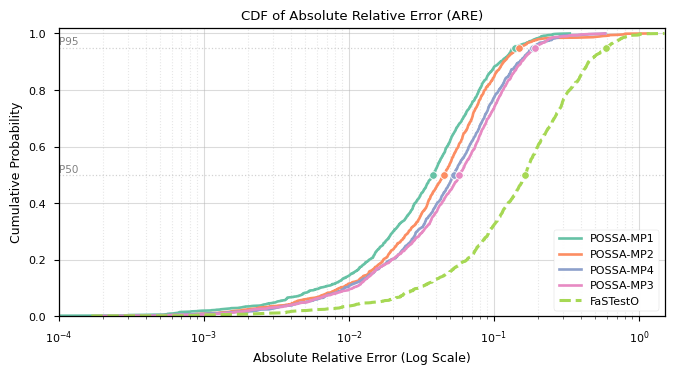

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import random
import json

# ==========================================
# 1. 配置
# ==========================================
agg_mode = 'count'
dataset = 'dataset_three'
fatestO_file = f'FastestO_budget_curve_{agg_mode}.csv'
N_SAMPLES = 5
ENABLE_FASTESTO = True

# 定义要在 CDF 图上标记的关键分位点 (例如: P50 和 P95)
MARK_PERCENTILES = [0.50, 0.95]
TARGET_BUDGET = 0.1

T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency/{fatestO_file}"
path_ablation = os.path.join(base_dir, f"proxy_quality_ablation_{agg_mode}.csv")

# PDF 输出目录
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"proxy_quality_cdf_{dataset}_vldb.pdf")

# 只读取这个单文件里的 POSSA 消融结果
RAW_PROXY_LABEL_MAP = {
    "POSSA_Q1_Low": "POSSA-MP4",
    "POSSA_Q2_Med": "POSSA-MP3",
    "POSSA_Q3_High": "POSSA-MP2",
    "POSSA_Q4_Best": "POSSA-MP1",
}
DISPLAY_ORDER = [
    "POSSA-MP1",
    "POSSA-MP2",
    "POSSA-MP4",
    "POSSA-MP3",
    "FaSTestO",
]

print(f"Dataset: {dataset}")
print(f"Ablation CSV: {path_ablation}")
print(f"T_true json: {T_TRUE_JSON}")

# ==========================================
# 1.1 VLDB 绘图规范（新增）
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,   # TrueType 嵌入（VLDB 常见要求）
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 8.5,
    "axes.labelsize": 9,
    "axes.titlesize": 9.5,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "axes.linewidth": 0.9,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.8
})

# ==========================================
# 2. 读取 T_true（唯一真值源）
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取单文件中的 POSSA 消融结果
# ==========================================
if not os.path.exists(path_ablation):
    raise FileNotFoundError(f"[Error] 找不到文件: {path_ablation}")

df_ablation = pd.read_csv(path_ablation)
df_ablation = standardize_name(df_ablation)

need_cols = {"query_basename", "method", "budget_frac", "T_hat", "T_true"}
miss = need_cols - set(df_ablation.columns)
if miss:
    raise ValueError(f"[Error] {path_ablation} 缺少列: {miss}")

# 只保留四个 POSSA 消融方法
df_ablation = df_ablation[df_ablation["method"].isin(RAW_PROXY_LABEL_MAP.keys())].copy()
df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
if df_ablation.empty:
    raise RuntimeError("proxy_quality_ablation_count.csv 中没有找到要比较的 POSSA 消融方法。")

# 映射成展示名，保持你原先图里的风格
df_ablation["method"] = df_ablation["method"].map(RAW_PROXY_LABEL_MAP)

# 统一使用 JSON 中的 T_true，并过滤无效值
df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
df_ablation["T_true"] = df_ablation["query_graph"].map(T_TRUE_MAP)
df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()

if df_ablation.empty:
    raise RuntimeError("POSSA 消融结果在对齐 T_true 后为空，请检查 query_basename 是否与 JSON 匹配。")

df_ablation = compute_are(df_ablation, "T_hat")
df_ablation["source"] = "ablation"

# 以 POSSA 四个方法为主计算共同查询
data_map = {}
for label in DISPLAY_ORDER:
    if label == "FaSTestO":
        continue
    tmp = df_ablation[df_ablation["method"] == label].copy()
    if not tmp.empty:
        data_map[label] = tmp
        print(f"[OK] {label}: {len(tmp)} rows")
    else:
        print(f"[WARN] {label}: 无可用数据")

if not data_map:
    raise RuntimeError("没有任何 POSSA 数据可绘图。")

common_queries = None
for label, df in data_map.items():
    qset = set(df["query_basename"].unique())
    common_queries = qset if common_queries is None else common_queries.intersection(qset)

if not common_queries:
    raise RuntimeError("POSSA 各方法之间没有共同查询，无法公平比较。")

print(f"[INFO] POSSA 共同查询数: {len(common_queries)}")

for label in list(data_map.keys()):
    df = data_map[label]
    data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

# ==========================================
# 4. 读取 FaSTestO（参照曲线）
# ==========================================
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)

    if "T_hat" in df_fast.columns:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()

        if not df_fast.empty:
            df_fast = compute_are(df_fast, "T_hat")
            data_map["FaSTestO"] = df_fast
            print(f"[OK] FaSTestO: {len(df_fast)} rows (aligned)")
        else:
            print("[WARN] FaSTestO 过滤后为空。")
    else:
        print("[WARN] FaSTestO 缺少 T_hat 列。")
else:
    print(f"[WARN] FaSTestO 跳过: {path_fastesto}")

# ==========================================
# 5. 生成统计表格 (Summary Table)
# ==========================================
def print_summary_table(data_dict):
    headers = ["Method", "Mean", "Median", "P50", "P75", "P90", "P95", "Max"]
    header_fmt = "{:<20} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10}"
    row_fmt    = "{:<20} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10}"

    line_len = 113
    print("\n" + "=" * line_len)
    print(f"{'AQP Evaluation Metrics Summary (Dynamic Percentiles)':^{line_len}}")
    print("=" * line_len)
    print(header_fmt.format(*headers))
    print("-" * line_len)

    # 保持固定顺序输出
    for label in DISPLAY_ORDER:
        if label not in data_dict:
            continue
        df = data_dict[label]
        are_series = df["ARE"]

        metrics = {
            "Mean":   are_series.mean() * 100,
            "Median": are_series.median() * 100,
            "P50":    np.percentile(are_series, 50) * 100,
            "P75":    np.percentile(are_series, 75) * 100,
            "P90":    np.percentile(are_series, 90) * 100,
            "P95":    np.percentile(are_series, 95) * 100,
            "Max":    are_series.max() * 100
        }

        f_metrics = [f"{v:.2f}%" for v in metrics.values()]
        print(row_fmt.format(label, *f_metrics))

    print("-" * line_len + "\n")

print_summary_table(data_map)

# ==========================================
# 6. 绘制 CDF (带标记) - VLDB 排版 + 矢量输出
# ==========================================
# 双栏友好尺寸；如果你要单栏可改成 (3.4, 2.6)
fig, ax = plt.subplots(figsize=(6.8, 3.8))

# 收集所有 ARE 以确定坐标轴范围
all_are = []
for df in data_map.values():
    all_are.extend(df["ARE"].values.tolist())

if not all_are:
    raise RuntimeError("没有可用于绘图的 ARE 数据。")

positive_are = [x for x in all_are if x > 0]
min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
upper_focus = np.quantile(all_are, 1.0)
upper_focus = max(upper_focus, min_are * 10)

# 曲线颜色保持不变（仍用 Set2）
palette = sns.color_palette("Set2", n_colors=len(data_map))
color_iter = iter(palette)

for label in DISPLAY_ORDER:
    if label not in data_map:
        continue

    df = data_map[label]
    subset = df["ARE"].sort_values()
    if subset.empty:
        continue

    n = len(subset)
    y_vals = np.arange(1, n + 1) / n

    ls = "--" if "FaSTestO" in label else "-"
    lw = 2.2 if "FaSTestO" in label else 1.9
    color = next(color_iter)

    ax.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)

    if MARK_PERCENTILES:
        marker_x = []
        marker_y = []
        for p in MARK_PERCENTILES:
            idx = int(p * n) - 1
            idx = max(0, min(idx, n - 1))
            val_x = subset.iloc[idx]
            marker_x.append(val_x)
            marker_y.append(p)

        ax.scatter(marker_x, marker_y, color=color, s=30, zorder=5, edgecolors='white', linewidth=0.6)

# 标题可保留；若投稿图统一由 caption 描述，可注释掉
ax.set_title("CDF of Absolute Relative Error (ARE)", pad=6)
ax.set_xlabel("Absolute Relative Error (Log Scale)")
ax.set_ylabel("Cumulative Probability")

ax.grid(True, which="major", linestyle="-", alpha=0.45)
ax.grid(True, which="minor", linestyle=":", alpha=0.30)

ax.set_xscale("log")
ax.set_xlim(min_are, upper_focus)
ax.set_ylim(0, 1.02)

for p in MARK_PERCENTILES:
    ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.9)
    ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=7.5)

ax.legend(loc="lower right", frameon=True, framealpha=0.95, edgecolor="0.8")
fig.tight_layout()

# 矢量 PDF 导出（关键）
fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"[OK] VLDB 风格矢量图已导出: {out_pdf}")

plt.show()
plt.close(fig)

#### 4.2 加上坐标

[OK] 完美格式 CDF 已导出: /home/wangshuo/resource/paper_figuires/RQ3_proxy_quality_cdf_Parler.pdf


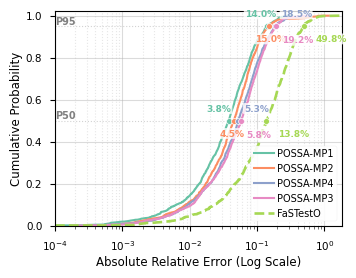

In [1]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置
# ==========================================
agg_mode = 'count'
dataset = 'dataset_three'
dataset_name = 'Parler'
fatestO_file = f'FastestO_budget_curve_{agg_mode}.csv'
ENABLE_FASTESTO = True

MARK_PERCENTILES = [0.50, 0.95]
TARGET_BUDGET = 0.1

T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency"
path_fastesto = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency/{fatestO_file}"
path_ablation = os.path.join(base_dir, f"proxy_quality_ablation_{agg_mode}.csv")

out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"RQ3_proxy_quality_cdf_{dataset_name}.pdf")

# 🚨 保持你原有的单谓词特定映射关系不变
RAW_PROXY_LABEL_MAP = {
    "POSSA_Q1_Low": "POSSA-MP4",
    "POSSA_Q2_Med": "POSSA-MP3",
    "POSSA_Q3_High": "POSSA-MP2",
    "POSSA_Q4_Best": "POSSA-MP1",
}
DISPLAY_ORDER = [
    "POSSA-MP1",
    "POSSA-MP2",
    "POSSA-MP4",
    "POSSA-MP3",
    "FaSTestO",
]

# 🚨 针对 5 条曲线在 X 轴上的分布设计的最优防重叠偏置字典 (x_offset, y_offset)
OFFSETS = {
    "POSSA-MP1": (-16, 7),   # 左上
    "POSSA-MP2": (-10, -11), # 左下
    "POSSA-MP4": (4, 7),     # 右上
    "POSSA-MP3": (4, -12), # 左下偏远
    "FaSTestO": (8, -11)     # 右下
}

# ==========================================
# 1.1 VLDB 极致学术紧凑排版规范
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,   # TrueType 嵌入
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 8.0,
    "axes.labelsize": 8.5,
    "axes.titlesize": 9.0,
    "legend.fontsize": 7.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5
})

# ==========================================
# 2. 读取 T_true
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取单文件中的 POSSA 消融结果
# ==========================================
if not os.path.exists(path_ablation):
    raise FileNotFoundError(f"[Error] 找不到文件: {path_ablation}")

df_ablation = pd.read_csv(path_ablation)
df_ablation = standardize_name(df_ablation)
df_ablation = df_ablation[df_ablation["method"].isin(RAW_PROXY_LABEL_MAP.keys())].copy()
df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
df_ablation["method"] = df_ablation["method"].map(RAW_PROXY_LABEL_MAP)

df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
df_ablation["T_true"] = df_ablation["query_graph"].map(T_TRUE_MAP)
df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
df_ablation = compute_are(df_ablation, "T_hat")

data_map = {}
for label in DISPLAY_ORDER:
    if label == "FaSTestO":
        continue
    tmp = df_ablation[df_ablation["method"] == label].copy()
    if not tmp.empty:
        data_map[label] = tmp

common_queries = None
for label, df in data_map.items():
    qset = set(df["query_basename"].unique())
    common_queries = qset if common_queries is None else common_queries.intersection(qset)

for label in list(data_map.keys()):
    df = data_map[label]
    data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

# ==========================================
# 4. 读取 FaSTestO
# ==========================================
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)
    if "T_hat" in df_fast.columns:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
        if not df_fast.empty:
            df_fast = compute_are(df_fast, "T_hat")
            data_map["FaSTestO"] = df_fast

# ==========================================
# 5. 绘制极致紧凑版 CDF
# ==========================================
# 🚨 论文双栏排版单侧黄金尺寸 (3.4, 2.6)
fig, ax = plt.subplots(figsize=(3.4, 2.6))

all_are = []
for df in data_map.values():
    all_are.extend(df["ARE"].values.tolist())

positive_are = [x for x in all_are if x > 0]
min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
upper_focus = np.quantile(all_are, 1.0)
upper_focus = max(upper_focus, min_are * 10)

palette = sns.color_palette("Set2", n_colors=len(data_map))
color_iter = iter(palette)

for label in DISPLAY_ORDER:
    if label not in data_map:
        continue

    df = data_map[label]
    subset = df["ARE"].sort_values()
    if subset.empty:
        continue

    n = len(subset)
    y_vals = np.arange(1, n + 1) / n

    ls = "--" if "FaSTestO" in label else "-"
    lw = 1.9 if "FaSTestO" in label else 1.5
    color = next(color_iter)

    ax.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)

    # 🚨 绘制并加粗标注 P50 & P95 数据点
    if MARK_PERCENTILES:
        for p in MARK_PERCENTILES:
            idx = int(p * n) - 1
            idx = max(0, min(idx, n - 1))
            val_x = subset.iloc[idx]
            
            # 画白色描边小圆点
            ax.scatter(val_x, p, color=color, s=18, zorder=5, edgecolors='white', linewidth=0.5)
            
            # 动态获取不重叠偏置
            off_x, off_y = OFFSETS.get(label, (5, 5))
            
            # 加粗标注真实误差值 (%)，带白色半透明背景防网格干扰
            ax.annotate(
                f"{val_x * 100:.1f}%",
                xy=(val_x, p),
                xytext=(off_x, off_y),
                textcoords="offset points",
                fontsize=6.5,
                fontweight="bold",
                color=color,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.8, ec="none"),
                zorder=6
            )

# ax.set_title("Parler (Single-Predicate)", pad=4, fontweight="bold")
ax.set_xlabel("Absolute Relative Error (Log Scale)", labelpad=2)
ax.set_ylabel("Cumulative Probability", labelpad=2)

ax.grid(True, which="major", linestyle="-", alpha=0.45)
ax.grid(True, which="minor", linestyle=":", alpha=0.30)

ax.set_xscale("log")
ax.set_xlim(min_are, upper_focus)
ax.set_ylim(0, 1.02)

for p in MARK_PERCENTILES:
    ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.8)
    ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=7.0, fontweight="bold")

ax.legend(loc="lower right", frameon=True, framealpha=0.9, edgecolor="0.9", handletextpad=0.4, borderpad=0.3)
fig.tight_layout(pad=0.02)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"[OK] 完美格式 CDF 已导出: {out_pdf}")
plt.show()
plt.close(fig)

[OK] 完美格式 CDF 已导出: /home/wangshuo/resource/paper_figuires/RQ3_proxy_quality_cdf_Parler.pdf


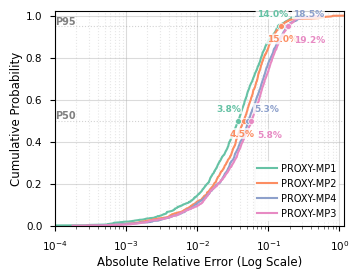

In [3]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置
# ==========================================
agg_mode = 'count'
dataset = 'dataset_three'
dataset_name = 'Parler'
FASTEST_ORACLE_file = f'FASTEST_ORACLE_budget_curve_{agg_mode}.csv'
ENABLE_FASTEST_ORACLE = True

MARK_PERCENTILES = [0.50, 0.95]
TARGET_BUDGET = 0.1

T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_{agg_mode}.json"
base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency"
path_fastest_oracle = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency/{FASTEST_ORACLE_file}"
path_ablation = os.path.join(base_dir, f"proxy_quality_ablation_{agg_mode}.csv")

out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"RQ3_proxy_quality_cdf_{dataset_name}.pdf")

# 🚨 保持你原有的单谓词特定映射关系不变
RAW_PROXY_LABEL_MAP = {
    "POSSA_Q1_Low": "PROXY-MP4",
    "POSSA_Q2_Med": "PROXY-MP3",
    "POSSA_Q3_High": "PROXY-MP2",
    "POSSA_Q4_Best": "PROXY-MP1",
}
DISPLAY_ORDER = [
    "PROXY-MP1",
    "PROXY-MP2",
    "PROXY-MP4",
    "PROXY-MP3",
    "FASTEST_ORACLE",
]

# 🚨 针对 5 条曲线在 X 轴上的分布设计的最优防重叠偏置字典 (x_offset, y_offset)
OFFSETS = {
    "PROXY-MP1": (-16, 7),   # 左上
    "PROXY-MP2": (-10, -11), # 左下
    "PROXY-MP4": (4, 7),     # 右上
    "PROXY-MP3": (4, -12), # 左下偏远
    "FASTEST_ORACLE": (8, -11)     # 右下
}

# ==========================================
# 1.1 VLDB 极致学术紧凑排版规范
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,   # TrueType 嵌入
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 8.0,
    "axes.labelsize": 8.5,
    "axes.titlesize": 9.0,
    "legend.fontsize": 7.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5
})

# ==========================================
# 2. 读取 T_true
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取单文件中的 POSSA 消融结果
# ==========================================
if not os.path.exists(path_ablation):
    raise FileNotFoundError(f"[Error] 找不到文件: {path_ablation}")

df_ablation = pd.read_csv(path_ablation)
df_ablation = standardize_name(df_ablation)
df_ablation = df_ablation[df_ablation["method"].isin(RAW_PROXY_LABEL_MAP.keys())].copy()
df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
df_ablation["method"] = df_ablation["method"].map(RAW_PROXY_LABEL_MAP)

df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
df_ablation["T_true"] = df_ablation["query_graph"].map(T_TRUE_MAP)
df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
df_ablation = compute_are(df_ablation, "T_hat")

data_map = {}
for label in DISPLAY_ORDER:
    if label == "FASTEST_ORACLE":
        continue
    tmp = df_ablation[df_ablation["method"] == label].copy()
    if not tmp.empty:
        data_map[label] = tmp

common_queries = None
for label, df in data_map.items():
    qset = set(df["query_basename"].unique())
    common_queries = qset if common_queries is None else common_queries.intersection(qset)

for label in list(data_map.keys()):
    df = data_map[label]
    data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

# ==========================================
# 4. 读取 FASTEST_ORACLE
# ==========================================
if ENABLE_FASTEST_ORACLE and os.path.exists(path_fastest_oracle):
    df_fast = pd.read_csv(path_fastest_oracle)
    df_fast = standardize_name(df_fast)
    if "T_hat" in df_fast.columns:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
        if not df_fast.empty:
            df_fast = compute_are(df_fast, "T_hat")
            data_map["FASTEST_ORACLE"] = df_fast

# ==========================================
# 5. 绘制极致紧凑版 CDF
# ==========================================
# 🚨 论文双栏排版单侧黄金尺寸 (3.4, 2.6)
fig, ax = plt.subplots(figsize=(3.4, 2.6))

all_are = []
for df in data_map.values():
    all_are.extend(df["ARE"].values.tolist())

positive_are = [x for x in all_are if x > 0]
min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
upper_focus = np.quantile(all_are, 1.0)
upper_focus = max(upper_focus, min_are * 10)

palette = sns.color_palette("Set2", n_colors=len(data_map))
color_iter = iter(palette)

for label in DISPLAY_ORDER:
    if label not in data_map:
        continue

    df = data_map[label]
    subset = df["ARE"].sort_values()
    if subset.empty:
        continue

    n = len(subset)
    y_vals = np.arange(1, n + 1) / n

    ls = "-"
    lw = 1.9 if "FASTEST_ORACLE" in label else 1.5
    color = next(color_iter)

    ax.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)

    # 🚨 绘制并加粗标注 P50 & P95 数据点
    if MARK_PERCENTILES:
        for p in MARK_PERCENTILES:
            idx = int(p * n) - 1
            idx = max(0, min(idx, n - 1))
            val_x = subset.iloc[idx]
            
            # 画白色描边小圆点
            ax.scatter(val_x, p, color=color, s=18, zorder=5, edgecolors='white', linewidth=0.5)
            
            # 动态获取不重叠偏置
            off_x, off_y = OFFSETS.get(label, (5, 5))
            
            # 加粗标注真实误差值 (%)，带白色半透明背景防网格干扰
            ax.annotate(
                f"{val_x * 100:.1f}%",
                xy=(val_x, p),
                xytext=(off_x, off_y),
                textcoords="offset points",
                fontsize=6.5,
                fontweight="bold",
                color=color,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.8, ec="none"),
                zorder=6
            )

# ax.set_title("Parler (Single-Predicate)", pad=4, fontweight="bold")
ax.set_xlabel("Absolute Relative Error (Log Scale)", labelpad=2)
ax.set_ylabel("Cumulative Probability", labelpad=2)

ax.grid(True, which="major", linestyle="-", alpha=0.45)
ax.grid(True, which="minor", linestyle=":", alpha=0.30)

ax.set_xscale("log")
ax.set_xlim(min_are, upper_focus)
ax.set_ylim(0, 1.02)

for p in MARK_PERCENTILES:
    ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.8)
    ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=7.0, fontweight="bold")

ax.legend(loc="lower right", frameon=True, framealpha=0.9, edgecolor="0.9", handletextpad=0.4, borderpad=0.3)
fig.tight_layout(pad=0.02)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"[OK] 完美格式 CDF 已导出: {out_pdf}")
plt.show()
plt.close(fig)

### 5. 不同代理模型-多推理谓词

#### 5.1 

Dataset: dataset_test
Ablation CSV: /home/wangshuo/resource/datasets/parler_data/dataset_test/results/efficiency/proxy_quality_multipred_ablation_count.csv
T_true json: /home/wangshuo/resource/datasets/parler_data/dataset_test/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json
[OK] POSSA-MP1: 550 rows
[OK] POSSA-MP2: 550 rows
[OK] POSSA-MP4: 550 rows
[OK] POSSA-MP3: 550 rows
[INFO] POSSA 共同查询数: 110
[OK] FaSTestO: 550 rows (aligned)

                                  Multi-Predicate AQP Evaluation Summary (ARE)                                   
Method               |       Mean |     Median |        P50 |        P75 |        P90 |        P95 |        Max
-----------------------------------------------------------------------------------------------------------------
POSSA-MP1            |      5.60% |      2.79% |      2.79% |      5.38% |     11.93% |     17.62% |    100.00%
POSSA-MP2            |      7.16% |      3.81% |      3.81% |      6.86% |     15.94% | 

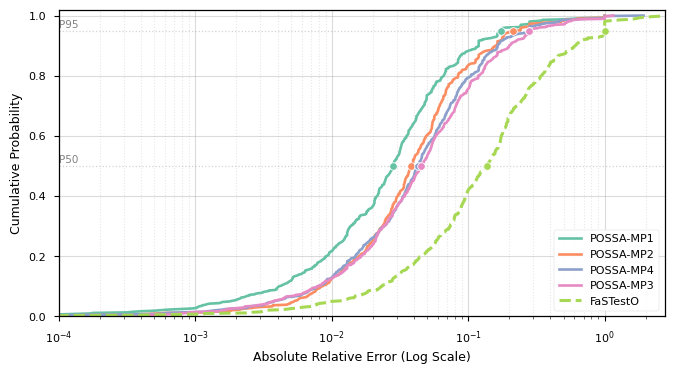

In [9]:
import pandas as pd
# import matplotlib.subplots as plt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os
import json

# ==========================================
# 1. 配置
# ==========================================
agg_mode = 'count'
# 多谓词实验默认在 dataset_test 下运行
dataset = 'dataset_test'  
fatestO_file = f'FastestO_budget_curve_{agg_mode}.csv'
ENABLE_FASTESTO = True

# 定义要在 CDF 图上标记的关键分位点 (例如: P50 和 P95)
MARK_PERCENTILES = [0.50, 0.95]
TARGET_BUDGET = 0.1

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency"
path_fastesto = os.path.join(base_dir, fatestO_file)

# 对应刚才多谓词实验保存的 CSV 文件
path_ablation = os.path.join(base_dir, "proxy_quality_multipred_ablation_count.csv")

# T_true 真值文件读取，加入 _count 兼容
T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json"
if not os.path.exists(T_TRUE_JSON):
    T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"


# PDF 输出目录
out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"proxy_quality_multipred_cdf_{dataset}_vldb.pdf")

# ==========================================
# 映射刚才跑出的结果列名到绘制用的名称
# Q1_Best (最优成对组合) -> POSSA-MP1
# Q4_Low (最差成对组合) -> POSSA-MP4
# ==========================================
RAW_PROXY_LABEL_MAP = {
    "POSSA_Q4_Low": "POSSA-MP4",   # 最差的一对 Proxy
    "POSSA_Q3_Med": "POSSA-MP3",
    "POSSA_Q2_High": "POSSA-MP2",
    "POSSA_Q1_Best": "POSSA-MP1",  # 最好的一对 Proxy
}
DISPLAY_ORDER = [
    "POSSA-MP1",
    "POSSA-MP2",
    "POSSA-MP4",
    "POSSA-MP3",
    "FaSTestO",
]

print(f"Dataset: {dataset}")
print(f"Ablation CSV: {path_ablation}")
print(f"T_true json: {T_TRUE_JSON}")

x = True
if x:
    # ==========================================
    # 1.1 VLDB 绘图规范
    # ==========================================
    try:
        plt.style.use("seaborn-v0_8-paper")
    except Exception:
        plt.style.use("seaborn-paper")

    plt.rcParams.update({
        "pdf.fonttype": 42,   # TrueType 嵌入（VLDB 常见要求）
        "ps.fonttype": 42,
        "font.family": "sans-serif",
        "font.size": 8.5,
        "axes.labelsize": 9,
        "axes.titlesize": 9.5,
        "legend.fontsize": 8,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "axes.linewidth": 0.9,
        "grid.linestyle": ":",
        "grid.alpha": 0.35,
        "lines.linewidth": 1.8
    })

    # ==========================================
    # 2. 读取 T_true（唯一真值源）
    # ==========================================
    if not os.path.exists(T_TRUE_JSON):
        raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

    with open(T_TRUE_JSON, "r") as f:
        T_TRUE_MAP = json.load(f)

    def to_graph_name(name: str) -> str:
        name = str(name)
        return name if name.endswith(".graph") else name + ".graph"

    def standardize_name(df):
        if df is not None and 'query_basename' in df.columns:
            df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
        return df

    def compute_are(df, t_hat_col="T_hat"):
        eps = 1e-9
        df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
        return df

    # ==========================================
    # 3. 读取单文件中的 POSSA 消融结果
    # ==========================================
    if not os.path.exists(path_ablation):
        raise FileNotFoundError(f"[Error] 找不到多谓词消融结果文件: {path_ablation}\n请先确保上一步跑完该脚本。")

    df_ablation = pd.read_csv(path_ablation)
    df_ablation = standardize_name(df_ablation)

    need_cols = {"query_basename", "method", "budget_frac", "T_hat"}
    miss = need_cols - set(df_ablation.columns)
    if miss:
        raise ValueError(f"[Error] {path_ablation} 缺少列: {miss}")

    # 只保留四个 POSSA 消融方法
    df_ablation = df_ablation[df_ablation["method"].isin(RAW_PROXY_LABEL_MAP.keys())].copy()
    df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
    if df_ablation.empty:
        raise RuntimeError("proxy_quality_multipred_ablation_count.csv 中没有找到要比较的 POSSA 消融方法 (budget 0.1)。")

    # 映射成展示名
    df_ablation["method"] = df_ablation["method"].map(RAW_PROXY_LABEL_MAP)

    # 统一使用 JSON 中的 T_true，并过滤无效值
    df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
    df_ablation["T_true"] = df_ablation["query_graph"].map(T_TRUE_MAP)
    df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()

    if df_ablation.empty:
        raise RuntimeError("POSSA 消融结果在对齐 T_true 后为空，请检查 query_basename 是否与 JSON 匹配。")

    df_ablation = compute_are(df_ablation, "T_hat")

    # 以 POSSA 四个方法为主计算共同查询
    data_map = {}
    for label in DISPLAY_ORDER:
        if label == "FaSTestO":
            continue
        tmp = df_ablation[df_ablation["method"] == label].copy()
        if not tmp.empty:
            data_map[label] = tmp
            print(f"[OK] {label}: {len(tmp)} rows")
        else:
            print(f"[WARN] {label}: 无可用数据")

    if not data_map:
        raise RuntimeError("没有任何 POSSA 数据可绘图。")

    common_queries = None
    for label, df in data_map.items():
        qset = set(df["query_basename"].unique())
        common_queries = qset if common_queries is None else common_queries.intersection(qset)

    if not common_queries:
        raise RuntimeError("POSSA 各方法之间没有共同查询，无法公平比较。")

    print(f"[INFO] POSSA 共同查询数: {len(common_queries)}")

    for label in list(data_map.keys()):
        df = data_map[label]
        data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

    # ==========================================
    # 4. 读取 FaSTestO（参照曲线）
    # ==========================================
    if ENABLE_FASTESTO and os.path.exists(path_fastesto):
        df_fast = pd.read_csv(path_fastesto)
        df_fast = standardize_name(df_fast)

        if "T_hat" in df_fast.columns:
            df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
            df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
            df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
            df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
            df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()

            if not df_fast.empty:
                df_fast = compute_are(df_fast, "T_hat")
                data_map["FaSTestO"] = df_fast
                print(f"[OK] FaSTestO: {len(df_fast)} rows (aligned)")
            else:
                print("[WARN] FaSTestO 过滤后为空。")
        else:
            print("[WARN] FaSTestO 缺少 T_hat 列。")
    else:
        print(f"[WARN] FaSTestO 跳过: {path_fastesto} 文件可能不存在")

    # ==========================================
    # 5. 生成统计表格 (Summary Table)
    # ==========================================
    def print_summary_table(data_dict):
        headers = ["Method", "Mean", "Median", "P50", "P75", "P90", "P95", "Max"]
        header_fmt = "{:<20} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10}"
        row_fmt    = "{:<20} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10} | {:>10}"

        line_len = 113
        print("\n" + "=" * line_len)
        print(f"{'Multi-Predicate AQP Evaluation Summary (ARE)':^{line_len}}")
        print("=" * line_len)
        print(header_fmt.format(*headers))
        print("-" * line_len)

        # 保持固定顺序输出
        for label in DISPLAY_ORDER:
            if label not in data_dict:
                continue
            df = data_dict[label]
            are_series = df["ARE"]

            metrics = {
                "Mean":   are_series.mean() * 100,
                "Median": are_series.median() * 100,
                "P50":    np.percentile(are_series, 50) * 100,
                "P75":    np.percentile(are_series, 75) * 100,
                "P90":    np.percentile(are_series, 90) * 100,
                "P95":    np.percentile(are_series, 95) * 100,
                "Max":    are_series.max() * 100
            }

            f_metrics = [f"{v:.2f}%" for v in metrics.values()]
            print(row_fmt.format(label, *f_metrics))

        print("-" * line_len + "\n")

    print_summary_table(data_map)

    # ==========================================
    # 6. 绘制 CDF (带标记) - VLDB 排版 + 矢量输出
    # ==========================================
    fig, ax = plt.subplots(figsize=(6.8, 3.8))

    # 收集所有 ARE 以确定坐标轴范围
    all_are = []
    for df in data_map.values():
        all_are.extend(df["ARE"].values.tolist())

    if not all_are:
        raise RuntimeError("没有可用于绘图的 ARE 数据。")

    positive_are = [x for x in all_are if x > 0]
    min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
    upper_focus = np.quantile(all_are, 1.0)
    upper_focus = max(upper_focus, min_are * 10)

    palette = sns.color_palette("Set2", n_colors=len(data_map))
    color_iter = iter(palette)

    for label in DISPLAY_ORDER:
        if label not in data_map:
            continue

        df = data_map[label]
        subset = df["ARE"].sort_values()
        if subset.empty:
            continue

        n = len(subset)
        y_vals = np.arange(1, n + 1) / n

        ls = "--" if "FaSTestO" in label else "-"
        lw = 2.2 if "FaSTestO" in label else 1.9
        color = next(color_iter)

        ax.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)

        if MARK_PERCENTILES:
            marker_x = []
            marker_y = []
            for p in MARK_PERCENTILES:
                idx = int(p * n) - 1
                idx = max(0, min(idx, n - 1))
                val_x = subset.iloc[idx]
                marker_x.append(val_x)
                marker_y.append(p)

            ax.scatter(marker_x, marker_y, color=color, s=30, zorder=5, edgecolors='white', linewidth=0.6)

    ax.set_xlabel("Absolute Relative Error (Log Scale)")
    ax.set_ylabel("Cumulative Probability")

    ax.grid(True, which="major", linestyle="-", alpha=0.45)
    ax.grid(True, which="minor", linestyle=":", alpha=0.30)

    ax.set_xscale("log")
    ax.set_xlim(min_are, upper_focus)
    ax.set_ylim(0, 1.02)

    for p in MARK_PERCENTILES:
        ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.9)
        ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=7.5)

    ax.legend(loc="lower right", frameon=True, framealpha=0.95, edgecolor="0.8")
    fig.tight_layout()

    # 矢量 PDF 导出（关键）
    fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
    print(f"[OK] VLDB 风格矢量图已导出: {out_pdf}")

    plt.show()
    plt.close(fig)

#### 5.2 加上erorr坐标

[OK] 完美格式 CDF 已导出: /home/wangshuo/resource/paper_figuires/RQ3_proxy_quality_multipred_cdf_Parler-E.pdf


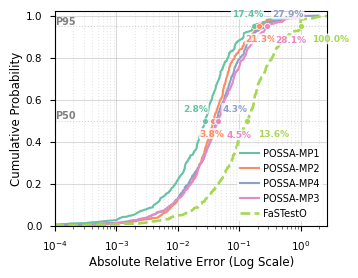

In [15]:
import os
import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. 配置
# ==========================================
agg_mode = 'count'
dataset = 'dataset_test'
dataset_name = 'Parler-E'  
fatestO_file = f'FastestO_budget_curve_{agg_mode}.csv'
ENABLE_FASTESTO = True

MARK_PERCENTILES = [0.50, 0.95]
TARGET_BUDGET = 0.1

base_dir = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/efficiency"
path_fastesto = os.path.join(base_dir, fatestO_file)
path_ablation = os.path.join(base_dir, "proxy_quality_multipred_ablation_count.csv")

# T_true 真值文件读取
T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability_count.json"
if not os.path.exists(T_TRUE_JSON):
    T_TRUE_JSON = f"/home/wangshuo/resource/datasets/parler_data/{dataset}/results/T_true_ML1_oracle2_probability_ML2_oracle2_probability.json"

out_dir = os.path.join("/home/wangshuo/resource", "paper_figuires")
os.makedirs(out_dir, exist_ok=True)
out_pdf = os.path.join(out_dir, f"RQ3_proxy_quality_multipred_cdf_{dataset_name}.pdf")

RAW_PROXY_LABEL_MAP = {
    "POSSA_Q4_Low": "POSSA-MP4",
    "POSSA_Q3_Med": "POSSA-MP3",
    "POSSA_Q2_High": "POSSA-MP2",
    "POSSA_Q1_Best": "POSSA-MP1",
}
DISPLAY_ORDER = [
    "POSSA-MP1",
    "POSSA-MP2",
    "POSSA-MP4",
    "POSSA-MP3",
    "FaSTestO",
]

# 🚨 针对 5 条曲线在 X 轴上的分布设计的最优防重叠偏置字典 (x_offset, y_offset)
OFFSETS = {
    "POSSA-MP1": (-16, 7),   # 左上
    "POSSA-MP2": (-10, -11), # 左下
    "POSSA-MP4": (4, 7),     # 右上
    "POSSA-MP3": (6, -12), # 左下偏远
    "FaSTestO": (8, -11)     # 右下
}

# ==========================================
# 1.1 VLDB 极致学术紧凑排版规范
# ==========================================
try:
    plt.style.use("seaborn-v0_8-paper")
except Exception:
    plt.style.use("seaborn-paper")

plt.rcParams.update({
    "pdf.fonttype": 42,   # TrueType 嵌入
    "ps.fonttype": 42,
    "font.family": "sans-serif",
    "font.size": 8.0,
    "axes.labelsize": 8.5,
    "axes.titlesize": 9.0,
    "legend.fontsize": 7.0,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "axes.linewidth": 0.8,
    "grid.linestyle": ":",
    "grid.alpha": 0.35,
    "lines.linewidth": 1.5
})

# ==========================================
# 2. 读取 T_true
# ==========================================
if not os.path.exists(T_TRUE_JSON):
    raise FileNotFoundError(f"T_true JSON 不存在: {T_TRUE_JSON}")

with open(T_TRUE_JSON, "r") as f:
    T_TRUE_MAP = json.load(f)

def to_graph_name(name: str) -> str:
    name = str(name)
    return name if name.endswith(".graph") else name + ".graph"

def standardize_name(df):
    if df is not None and 'query_basename' in df.columns:
        df['query_basename'] = df['query_basename'].astype(str).str.replace(r'\.graph$', '', regex=True)
    return df

def compute_are(df, t_hat_col="T_hat"):
    eps = 1e-9
    df["ARE"] = (df[t_hat_col].astype(float) - df["T_true"].astype(float)).abs() / (df["T_true"].astype(float) + eps)
    return df

# ==========================================
# 3. 读取单文件中的 POSSA 消融结果
# ==========================================
if not os.path.exists(path_ablation):
    raise FileNotFoundError(f"[Error] 找不到多谓词消融结果文件: {path_ablation}")

df_ablation = pd.read_csv(path_ablation)
df_ablation = standardize_name(df_ablation)
df_ablation = df_ablation[df_ablation["method"].isin(RAW_PROXY_LABEL_MAP.keys())].copy()
df_ablation = df_ablation[np.isclose(df_ablation["budget_frac"], TARGET_BUDGET)].copy()
df_ablation["method"] = df_ablation["method"].map(RAW_PROXY_LABEL_MAP)

df_ablation["query_graph"] = df_ablation["query_basename"].apply(to_graph_name)
df_ablation["T_true"] = df_ablation["query_graph"].map(T_TRUE_MAP)
df_ablation = df_ablation[df_ablation["T_true"].notna() & (df_ablation["T_true"] > 0)].copy()
df_ablation = compute_are(df_ablation, "T_hat")

data_map = {}
for label in DISPLAY_ORDER:
    if label == "FaSTestO":
        continue
    tmp = df_ablation[df_ablation["method"] == label].copy()
    if not tmp.empty:
        data_map[label] = tmp

common_queries = None
for label, df in data_map.items():
    qset = set(df["query_basename"].unique())
    common_queries = qset if common_queries is None else common_queries.intersection(qset)

for label in list(data_map.keys()):
    df = data_map[label]
    data_map[label] = df[df["query_basename"].isin(common_queries)].copy()

# ==========================================
# 4. 读取 FaSTestO
# ==========================================
if ENABLE_FASTESTO and os.path.exists(path_fastesto):
    df_fast = pd.read_csv(path_fastesto)
    df_fast = standardize_name(df_fast)
    if "T_hat" in df_fast.columns:
        df_fast["query_graph"] = df_fast["query_basename"].apply(to_graph_name)
        df_fast = df_fast[np.isclose(df_fast["budget_frac"], TARGET_BUDGET)].copy()
        df_fast["T_true"] = df_fast["query_graph"].map(T_TRUE_MAP)
        df_fast = df_fast[df_fast["T_true"].notna() & (df_fast["T_true"] > 0)].copy()
        df_fast = df_fast[df_fast["query_basename"].isin(common_queries)].copy()
        if not df_fast.empty:
            df_fast = compute_are(df_fast, "T_hat")
            data_map["FaSTestO"] = df_fast

# ==========================================
# 5. 绘制极致紧凑版 CDF
# ==========================================
# 🚨 论文双栏排版单侧黄金尺寸 (3.4, 2.6)
fig, ax = plt.subplots(figsize=(3.4, 2.6))

all_are = []
for df in data_map.values():
    all_are.extend(df["ARE"].values.tolist())

positive_are = [x for x in all_are if x > 0]
min_are = max(1e-4, np.min(positive_are) if positive_are else 1e-4)
upper_focus = np.quantile(all_are, 1.0)
upper_focus = max(upper_focus, min_are * 10)

palette = sns.color_palette("Set2", n_colors=len(data_map))
color_iter = iter(palette)

for label in DISPLAY_ORDER:
    if label not in data_map:
        continue

    df = data_map[label]
    subset = df["ARE"].sort_values()
    if subset.empty:
        continue

    n = len(subset)
    y_vals = np.arange(1, n + 1) / n

    ls = "--" if "FaSTestO" in label else "-"
    lw = 1.9 if "FaSTestO" in label else 1.5
    color = next(color_iter)

    ax.plot(subset, y_vals, label=label, linewidth=lw, linestyle=ls, color=color)

    # 🚨 绘制并加粗标注 P50 & P95 数据点
    if MARK_PERCENTILES:
        for p in MARK_PERCENTILES:
            idx = int(p * n) - 1
            idx = max(0, min(idx, n - 1))
            val_x = subset.iloc[idx]
            
            # 画白色描边小圆点
            ax.scatter(val_x, p, color=color, s=18, zorder=5, edgecolors='white', linewidth=0.5)
            
            # 动态获取不重叠偏置
            off_x, off_y = OFFSETS.get(label, (5, 5))
            
            # 加粗标注真实误差值 (%)，带白色半透明背景防网格干扰
            ax.annotate(
                f"{val_x * 100:.1f}%",
                xy=(val_x, p),
                xytext=(off_x, off_y),
                textcoords="offset points",
                fontsize=6.5,
                fontweight="bold",
                color=color,
                bbox=dict(boxstyle="round,pad=0.1", fc="white", alpha=0.8, ec="none"),
                zorder=6
            )

# ax.set_title("Parler-E (Multi-Predicate)", pad=4, fontweight="bold")
ax.set_xlabel("Absolute Relative Error (Log Scale)", labelpad=2)
ax.set_ylabel("Cumulative Probability", labelpad=2)

ax.grid(True, which="major", linestyle="-", alpha=0.45)
ax.grid(True, which="minor", linestyle=":", alpha=0.30)

ax.set_xscale("log")
ax.set_xlim(min_are, upper_focus)
ax.set_ylim(0, 1.02)

for p in MARK_PERCENTILES:
    ax.axhline(y=p, color='gray', linestyle=':', alpha=0.35, linewidth=0.8)
    ax.text(min_are, p + 0.01, f"P{int(p*100)}", color='gray', fontsize=7.0, fontweight="bold")

ax.legend(loc="lower right", frameon=True, framealpha=0.9, edgecolor="0.9", handletextpad=0.4, borderpad=0.3)
fig.tight_layout(pad=0.02)

fig.savefig(out_pdf, format="pdf", bbox_inches="tight", pad_inches=0.02)
print(f"[OK] 完美格式 CDF 已导出: {out_pdf}")
plt.show()
plt.close(fig)